In [592]:
spike_clusters

array([352, 265,   2, ..., 220, 110, 380], shape=(6131481,), dtype=int32)

In [591]:
spike_templates

array([352, 265,   2, ..., 220, 110, 380], shape=(6131481,), dtype=int32)

In [595]:
np.shape(templates)

(395, 61, 380)

In [547]:
from __future__ import annotations

import re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

# ============================= USER SETTINGS =============================
dt_folder = Path(r"J:\project_trainingAggression\Data")
MOUSE = "975826"
OBS_ALLOWED = {f"obs{6}"}  # obs1..obs6
LABELS_GOOD = {"good"}

# ============================= PROCESS 1 (NO FUNCTIONS) =============================
# 0) Find all autoForNeuroConcat directories
auto_dirs = sorted([p for p in dt_folder.rglob("autoForNeuroConcat") if p.is_dir()])
print(f"[DEBUG] Found autoForNeuroConcat dirs: {len(auto_dirs)}")
if len(auto_dirs) > 0:
    print("[DEBUG] Example auto_dir:", auto_dirs[0])

rows = []

for auto_dir in auto_dirs:
    auto_dir_str = str(auto_dir)

    # 1) Mouse filter
    mouse_ok = re.search(rf"(?<!\d){re.escape(MOUSE)}(?!\d)", auto_dir_str) is not None
    if not mouse_ok:
        continue

    # 2) Parse obs ID from path
    m_obs = re.search(r"(?i)(obs[1-6])", auto_dir_str)
    obs = m_obs.group(1).lower() if m_obs else None
    print(f"\n[DEBUG] auto_dir={auto_dir}")
    print(f"[DEBUG] obs parsed: {obs}")

    if obs is None or obs not in OBS_ALLOWED:
        print(f"[DEBUG] obs not allowed -> skip (obs={obs}, OBS_ALLOWED={OBS_ALLOWED})")
        continue

    # 3) Probe label from path
    s_lower = auto_dir_str.lower()
    if "imec0" in s_lower:
        probe = "imec0"
    elif "imec1" in s_lower:
        probe = "imec1"
    elif "imec2" in s_lower:
        probe = "imec2"
    else:
        probe = "imec?"
    print(f"[DEBUG] probe parsed: {probe}")

    if probe not in {"imec0", "imec1", "imec2"}:
        print("[DEBUG] probe not recognized -> skip")
        continue

    # 4) Load GOOD cluster ids from autoForNeuroConcat (cluster_group.tsv preferred)
    cg = auto_dir / "cluster_group.tsv"
    ci = auto_dir / "cluster_info.tsv"
    print(f"[DEBUG] cluster_group.tsv exists: {cg.exists()}")
    print(f"[DEBUG] cluster_info.tsv exists: {ci.exists()}")

    good_ids = np.array([], dtype=np.int64)

    if cg.exists():
        df_cg = pd.read_csv(cg, sep="\t")
        print(f"[DEBUG] cluster_group.tsv columns: {list(df_cg.columns)}")
        if {"cluster_id", "group"}.issubset(df_cg.columns):
            grp = df_cg["group"].astype("string").str.strip().str.lower()
            good_ids = df_cg.loc[grp.isin(LABELS_GOOD), "cluster_id"].to_numpy(np.int64)
            good_ids = np.unique(good_ids)

    if good_ids.size == 0 and ci.exists():
        df_ci = pd.read_csv(ci, sep="\t")
        print(f"[DEBUG] cluster_info.tsv columns: {list(df_ci.columns)}")
        if {"cluster_id", "group"}.issubset(df_ci.columns):
            grp = df_ci["group"].astype("string").str.strip().str.lower()
            good_ids = df_ci.loc[grp.isin(LABELS_GOOD), "cluster_id"].to_numpy(np.int64)
            good_ids = np.unique(good_ids)

    print(f"[DEBUG] good_ids count: {good_ids.size}")
    if good_ids.size > 0:
        print("[DEBUG] good_ids example:", good_ids[:10])

    if good_ids.size == 0:
        print("[DEBUG] no GOOD ids -> skip")
        continue

    # 5) Find Kilosort directory above autoForNeuroConcat
    required = ["spike_clusters.npy", "spike_templates.npy", "templates.npy"]
    p = auto_dir
    ks_dir = None

    for step in range(12):
        # check p
        if all((p / f).exists() for f in required):
            ks_dir = p
            break
        # check parent
        if all((p.parent / f).exists() for f in required):
            ks_dir = p.parent
            break
        p = p.parent

    print(f"[DEBUG] ks_dir found: {ks_dir}")
    if ks_dir is None:
        raise FileNotFoundError(f"Could not find Kilosort outputs above: {auto_dir}")

    # 6) Load Kilosort arrays
    spike_clusters_path = ks_dir / "spike_clusters.npy"
    spike_templates_path = ks_dir / "spike_templates.npy"
    templates_path = ks_dir / "templates.npy"
    channel_map_path = ks_dir / "channel_map.npy"

    spike_clusters = np.load(spike_clusters_path)
    spike_templates = np.load(spike_templates_path)
    templates = np.load(templates_path)

    print(f"[DEBUG] spike_clusters shape: {spike_clusters.shape}, dtype={spike_clusters.dtype}")
    print(f"[DEBUG] spike_templates shape: {spike_templates.shape}, dtype={spike_templates.dtype}")
    print(f"[DEBUG] templates shape: {templates.shape}, dtype={templates.dtype}")

    # 7) Compute template peak channel (ptp across time)
    # templates: (n_templates, n_timepoints, n_channels_used)
    ptp = np.ptp(templates, axis=1)  # -> (n_templates, n_channels_used)
    template_peak_ch = ptp.argmax(axis=1).astype(int)
    print(f"[DEBUG] ptp shape: {ptp.shape}")
    print(f"[DEBUG] template_peak_ch shape: {template_peak_ch.shape}")
    print(f"[DEBUG] template_peak_ch example: {template_peak_ch[:10]}")

    channel_map = None
    if channel_map_path.exists():
        channel_map = np.load(channel_map_path).astype(int).flatten()
        print(f"[DEBUG] channel_map shape: {channel_map.shape}")
        print(f"[DEBUG] channel_map example: {channel_map[:10]}")
    else:
        print("[DEBUG] channel_map.npy not found (will use Kilosort channel indices)")

    # 8) Build cluster -> list of templates from spikes
    # (This is the part that can be slow; prints are kept light)
    cluster_to_templates = defaultdict(list)
    for c, t in zip(spike_clusters, spike_templates):
        cluster_to_templates[int(c)].append(int(t))

    print(f"[DEBUG] unique clusters in spike_clusters: {len(cluster_to_templates)}")

    # 9) cluster_id -> peak_channel via dominant template
    cluster_to_peak = {}
    # debug a couple clusters
    debug_some = 0

    for cid, t_list in cluster_to_templates.items():
        dom_t = Counter(t_list).most_common(1)[0][0]
        ch = int(template_peak_ch[dom_t])

        if channel_map is not None and 0 <= ch < len(channel_map):
            ch_mapped = int(channel_map[ch])
        else:
            ch_mapped = ch

        cluster_to_peak[cid] = ch_mapped

        if debug_some < 5:
            print(f"[DEBUG] cid={cid} dom_t={dom_t} peak_ch_used={ch} peak_ch_mapped={ch_mapped}")
            debug_some += 1

    # 10) catgt name from path
    m_catgt = re.search(r"(catgt_[^\\\/]+)", auto_dir_str)
    catgt = m_catgt.group(1) if m_catgt else auto_dir.parent.name
    print(f"[DEBUG] catgt parsed: {catgt}")

    # 11) Emit rows for each GOOD cluster occurrence
    missing_peak_for_good = 0
    for cid in good_ids.astype(int):
        peak = cluster_to_peak.get(int(cid), None)
        if peak is None:
            missing_peak_for_good += 1

        rows.append(
            {
                "mouse": MOUSE,
                "obs": obs,
                "probe": probe,
                "catgt": catgt,
                "cluster_id": int(cid),
                "peak_channel": peak,
                "auto_dir": str(auto_dir),
                "ks_dir": str(ks_dir),
            }
        )

    if missing_peak_for_good:
        print(f"[DEBUG] WARNING: {missing_peak_for_good} GOOD cluster_ids not found in cluster_to_peak map")

# 12) Final dataframe
good_units = pd.DataFrame(rows)
if not good_units.empty:
    good_units = good_units.sort_values(["mouse", "obs", "catgt", "probe", "cluster_id"]).reset_index(drop=True)

# 13) Report
if good_units.empty:
    raise RuntimeError(f"No GOOD units found for mouse {MOUSE} in obs1..obs6.")

print(f"\n[Process 1] Rows (GOOD cluster occurrences): {len(good_units)}")
print(good_units.head(10))

n_missing = good_units["peak_channel"].isna().sum()
if n_missing:
    print(f"[Process 1] WARNING: {n_missing} rows missing peak_channel")

[DEBUG] Found autoForNeuroConcat dirs: 378
[DEBUG] Example auto_dir: J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec0\Kilosort4_probe0\sorter_output\autoForNeuroConcat

[DEBUG] auto_dir=J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec0\Kilosort4_probe0\sorter_output\autoForNeuroConcat
[DEBUG] obs parsed: obs1
[DEBUG] obs not allowed -> skip (obs=obs1, OBS_ALLOWED={'obs6'})

[DEBUG] auto_dir=J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec1\Kilosort4_probe1\sorter_output\autoForNeuroConcat
[DEBUG] obs parsed: obs1
[DEBUG] obs not allowed -> skip (obs=obs1, OBS_ALLOWED={'obs6'})

[DEBUG] auto_dir=J:\project_trainingAggression\Data\20250817_mouse975826\Day01\neuralData\catgt_20250817_m975826_obs1_g0\20250817_m975826_obs1_g0_imec2\Kilosor

In [ ]:
import numpy as np
from pathlib import Path

def _best_monotonic_axis_and_sign(sites_loc_b_row: np.ndarray):
    """
    sites_loc_b_row: (n_sites, 3)
    Returns: (axis, sign) that maximizes monotonicity score.
    """
    best = None
    for ax in range(3):
        v = sites_loc_b_row[:, ax].astype(float)
        # ignore NaNs
        if np.sum(np.isfinite(v)) < 10:
            continue
        for sgn in (+1.0, -1.0):
            u = sgn * v
            # monotonicity score: fraction of positive diffs after sorting by index
            d = np.diff(u)
            score = np.nanmean(d > 0)  # closer to 1 means increasing
            span = np.nanmax(u) - np.nanmin(u)
            # prefer monotonic AND large span
            key = (score, span)
            if best is None or key > best[0]:
                best = (key, ax, sgn)
    if best is None:
        return 1, +1.0
    return best[1], best[2]

def _percentile(x: np.ndarray):
    """
    Map finite values in x to [0,1] by rank. NaNs remain NaN.
    """
    out = np.full_like(x, np.nan, dtype=float)
    m = np.isfinite(x)
    if m.sum() == 0:
        return out
    vals = x[m]
    order = np.argsort(vals)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.linspace(0.0, 1.0, len(vals), endpoint=True)
    out[m] = ranks
    return out

def build_channel_to_region_map_percentile(
    ks_dir: Path,
    site_depth: np.ndarray,
    site_label: np.ndarray,
    channel_positions_axis: int = 1,
):
    """
    Robust mapping: channel -> nearest HERBS site by percentile along probe.
    - site_depth: (128,) scalar coordinate along probe (already extracted from HERBS, for the chosen row/axis/sign)
    - site_label: (128,) region IDs for those sites
    - channel_positions_axis: use this axis from channel_positions (usually 1 == depth)
    Returns region_by_channel (len = channel index space you're using)
    """
    # ----- get channel depth from Kilosort geometry -----
    pos_path = ks_dir / "channel_positions.npy"
    if not pos_path.exists():
        raise FileNotFoundError(f"Missing {pos_path}")
    pos = np.load(pos_path)  # (n_ch_used, 2 or 3)
    if pos.shape[1] <= channel_positions_axis:
        raise ValueError(f"{pos_path} has shape {pos.shape}, cannot use axis {channel_positions_axis}")
    ch_depth_used = pos[:, channel_positions_axis].astype(float)

    # ----- expand to "original channel index space" if channel_map exists -----
    ch_map_path = ks_dir / "channel_map.npy"
    if ch_map_path.exists():
        channel_map = np.load(ch_map_path).astype(int).flatten()
        ch_depth = np.full(int(channel_map.max()) + 1, np.nan, dtype=float)
        ch_depth[channel_map] = ch_depth_used
    else:
        ch_depth = ch_depth_used

    # ----- compute percentiles for channels and sites -----
    site_p = _percentile(site_depth.astype(float))
    ch_p   = _percentile(ch_depth.astype(float))

    # sort sites by percentile (increasing)
    sidx = np.argsort(site_p)
    site_p_sorted = site_p[sidx]
    site_label_sorted = site_label[sidx].astype(np.int64)

    # map each channel percentile to nearest site percentile
    region_by_channel = np.full(len(ch_depth), -1, dtype=np.int64)

    finite = np.isfinite(ch_p)
    cp = ch_p[finite]
    ins = np.searchsorted(site_p_sorted, cp, side="left")
    ins = np.clip(ins, 0, len(site_p_sorted) - 1)
    left = np.clip(ins - 1, 0, len(site_p_sorted) - 1)
    right = ins

    dl = np.abs(cp - site_p_sorted[left])
    dr = np.abs(cp - site_p_sorted[right])
    nearest = np.where(dl <= dr, left, right)

    region_by_channel[np.where(finite)[0]] = site_label_sorted[nearest]
    return region_by_channel




TypeError: float() argument must be a string or a real number, not 'ellipsis'

In [518]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# ===================== USER SETTINGS =====================
HERBS_PROBE_PLK = {
    "imec0": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 1.pkl"),
    "imec1": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 2.pkl"),
    "imec2": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 3.pkl"),
}

# If you must use the fallback sites_loc_b method, which axis is depth-like
DEPTH_AXIS_FALLBACK = 1

# Align in normalized depth space (recommended unless you KNOW units match)
USE_NORMALIZED_DEPTH = True


def _normalize(v):
    """Normalize finite values of v to [0,1]. Returns normalized array and (min,max)."""
    v = np.asarray(v, dtype=float)
    out = np.full_like(v, np.nan, dtype=float)
    finite = np.isfinite(v)
    if finite.sum() < 2:
        return out, (np.nan, np.nan)
    vmin = np.nanmin(v[finite])
    vmax = np.nanmax(v[finite])
    if vmax == vmin:
        out[finite] = 0.5
        return out, (vmin, vmax)
    out[finite] = (v[finite] - vmin) / (vmax - vmin)
    return out, (vmin, vmax)


def _to_piece_list(x, name, probe_path):
    """Ragged-safe conversion to list-of-pieces arrays."""
    if isinstance(x, np.ndarray) and x.dtype != object and x.ndim >= 2:
        return [np.asarray(x[i]) for i in range(x.shape[0])]
    if isinstance(x, (list, tuple)):
        return [np.asarray(v) for v in x]
    if isinstance(x, np.ndarray) and x.dtype == object:
        return [np.asarray(v) for v in list(x)]
    raise TypeError(f"{probe_path}: {name} has unsupported type/shape: {type(x)} / {getattr(x, 'shape', None)}")


def _build_site_mapping_from_vis(probe_obj, probe_path):
    """
    Build a per-site mapping using:
      region_label (structure id list indexed by group_id)
      label_acronym, label_name (same indexing)
      vis_data[r]: dict with 'group_id', 'start_loc', 'end_loc', 'sites'
    Returns dict with:
      best_row, site_pos, site_region_id, id->(acronym,name)
    """
    d = probe_obj.get("data", probe_obj)

    needed = ["region_label", "label_acronym", "label_name", "vis_data"]
    if not all(k in d for k in needed):
        return None  # caller will fallback

    region_label = np.asarray(d["region_label"])
    label_acronym = list(d["label_acronym"])
    label_name = list(d["label_name"])
    vis_data = d["vis_data"]

    # Map group_id index -> actual atlas structure id / labels
    group_to_region_id = {gi: int(region_label[gi]) for gi in range(len(region_label))}
    group_to_acr = {gi: str(label_acronym[gi]) for gi in range(len(label_acronym))}
    group_to_name = {gi: str(label_name[gi]) for gi in range(len(label_name))}

    # pick best piece row: largest span in 'sites' coordinate
    spans = []
    for r in range(len(vis_data)):
        sites = np.asarray(vis_data[r]["sites"], dtype=float)
        spans.append(np.nanmax(sites) - np.nanmin(sites))
    best_row = int(np.nanargmax(spans))

    vd = vis_data[best_row]
    sites = np.asarray(vd["sites"], dtype=float)          # (n_sites,)
    start = np.asarray(vd["start_loc"], dtype=float)      # (n_segments,)
    end = np.asarray(vd["end_loc"], dtype=float)          # (n_segments,)
    gids = np.asarray(vd["group_id"], dtype=float)        # (n_segments,)

    # sanity
    if not (len(start) == len(end) == len(gids)):
        raise ValueError(f"{probe_path}: vis_data[{best_row}] start/end/group_id lengths mismatch")
    if np.any(end < start):
        raise ValueError(f"{probe_path}: vis_data[{best_row}] has end_loc < start_loc")

    # assign each site to segment: find first end_loc >= site
    # (sites are within [0,~104] in your example)
    seg_idx = np.searchsorted(end, sites, side="left")
    seg_idx = np.clip(seg_idx, 0, len(end) - 1)

    # If a site is before its segment's start (can happen at boundaries), nudge left if possible
    too_early = sites < start[seg_idx]
    seg_idx[too_early] = np.maximum(seg_idx[too_early] - 1, 0)

    gids_i = gids[seg_idx].astype(int)

    site_region_id = np.array([group_to_region_id.get(g, -1) for g in gids_i], dtype=np.int64)

    return {
        "best_row": best_row,
        "row_spans": spans,
        "site_pos": sites,
        "site_region_id": site_region_id,
        "group_to_region_id": group_to_region_id,
        "group_to_acr": group_to_acr,
        "group_to_name": group_to_name,
        "region_id_to_acr": {int(region_label[i]): str(label_acronym[i]) for i in range(len(region_label))},
        "region_id_to_name": {int(region_label[i]): str(label_name[i]) for i in range(len(region_label))},
        "mode": "vis_data",
    }


def _build_site_mapping_from_sites_loc_b(probe_obj, probe_path, depth_axis=1):
    """
    Fallback method (your old approach): choose best piece by span of sites_loc_b along depth_axis.
    Returns dict with best_row, site_pos, site_region_id, and label maps (only IDs available).
    """
    d = probe_obj.get("data", probe_obj)

    pieces_label = _to_piece_list(d["sites_label"], "sites_label", probe_path)
    pieces_loc_b = _to_piece_list(d["sites_loc_b"], "sites_loc_b", probe_path)

    spans = []
    for r in range(len(pieces_loc_b)):
        loc_r = np.asarray(pieces_loc_b[r])
        y = loc_r[:, depth_axis].astype(float)
        spans.append(np.nanmax(y) - np.nanmin(y))
    best_row = int(np.nanargmax(spans))

    loc = np.asarray(pieces_loc_b[best_row])
    lab = np.asarray(pieces_label[best_row]).reshape(-1).astype(np.int64)

    site_pos = loc[:, depth_axis].astype(float)
    return {
        "best_row": best_row,
        "row_spans": spans,
        "site_pos": site_pos,
        "site_region_id": lab,
        "region_id_to_acr": {},
        "region_id_to_name": {},
        "mode": "sites_loc_b",
    }


# ===================== LOAD HERBS PROBES & BUILD PER-PROBE SITE MAP =====================
herbs_maps = {}
for probe, probe_path in HERBS_PROBE_PLK.items():
    with open(probe_path, "rb") as f:
        probe_obj = pickle.load(f)

    m = _build_site_mapping_from_vis(probe_obj, probe_path)
    if m is None:
        m = _build_site_mapping_from_sites_loc_b(probe_obj, probe_path, depth_axis=DEPTH_AXIS_FALLBACK)

    herbs_maps[probe] = m

    # diagnostics
    site_pos = m["site_pos"]
    site_ids = m["site_region_id"]
    finite = np.isfinite(site_pos)
    uniq = np.unique(site_ids[site_ids != -1])

    print(f"[HERBS] {probe}: {probe_path.name} | mode={m['mode']} | selected_row={m['best_row']} | spans={np.round(m['row_spans'], 4)}")
    if finite.any():
        print(f"        site_pos range: {np.nanmin(site_pos[finite]):.4f} .. {np.nanmax(site_pos[finite]):.4f} (span {np.nanmax(site_pos[finite])-np.nanmin(site_pos[finite]):.4f})")
    print(f"        unique region_ids in probe map: {len(uniq)}")


# ===================== PREPARE OUTPUT DF =====================
aligned = good_units.copy()
aligned["region_id"] = -1
aligned["region_acronym"] = ""
aligned["region_name"] = ""
aligned["herbs_piece_row"] = -1


# ===================== BUILD CHANNEL->REGION MAP PER (ks_dir, probe) =====================
region_cache = {}  # (ks_dir_str, probe) -> (region_by_channel, best_row)

unique_sessions = sorted(aligned["ks_dir"].unique())
print(f"\n[ALIGN] Unique ks_dir sessions: {len(unique_sessions)}")

for ks_dir_str in unique_sessions:
    ks_dir = Path(ks_dir_str)

    pos_path = ks_dir / "channel_positions.npy"
    if not pos_path.exists():
        raise FileNotFoundError(f"Missing {pos_path}")
    pos = np.load(pos_path)
    if pos.ndim != 2 or pos.shape[1] < 2:
        raise ValueError(f"{pos_path}: expected (n_channels, >=2). Got {pos.shape}")
    ch_depth_used = pos[:, 1].astype(float)

    # map to original index space if channel_map exists (so indices match peak_channel)
    ch_map_path = ks_dir / "channel_map.npy"
    if ch_map_path.exists():
        channel_map = np.load(ch_map_path).astype(int).flatten()
        ch_depth = np.full(int(channel_map.max()) + 1, np.nan, dtype=float)
        ch_depth[channel_map] = ch_depth_used
    else:
        ch_depth = ch_depth_used

    # build for each probe
    for probe, m in herbs_maps.items():
        site_pos = np.asarray(m["site_pos"], dtype=float)
        site_region_id = np.asarray(m["site_region_id"], dtype=np.int64)
        best_row = int(m["best_row"])

        # sort by site_pos
        sidx = np.argsort(site_pos)
        sp = site_pos[sidx]
        sr = site_region_id[sidx]

        # drop NaN site positions
        keep = np.isfinite(sp)
        sp = sp[keep]
        sr = sr[keep]
        if len(sp) < 2:
            raise ValueError(f"{probe}: too few finite site positions to align")

        # choose comparison depth space
        if USE_NORMALIZED_DEPTH:
            sp_cmp, _ = _normalize(sp)
            cd_cmp, _ = _normalize(ch_depth)
        else:
            sp_cmp = sp
            cd_cmp = ch_depth

        region_by_channel = np.full(len(ch_depth), -1, dtype=np.int64)

        finite = np.isfinite(cd_cmp)
        cd = cd_cmp[finite].astype(float)

        # nearest neighbor in depth
        ins = np.searchsorted(sp_cmp, cd, side="left")
        ins = np.clip(ins, 0, len(sp_cmp) - 1)

        left = np.clip(ins - 1, 0, len(sp_cmp) - 1)
        right = ins

        dl = np.abs(cd - sp_cmp[left])
        dr = np.abs(cd - sp_cmp[right])
        nearest = np.where(dl <= dr, left, right)

        region_by_channel[np.where(finite)[0]] = sr[nearest]
        region_cache[(ks_dir_str, probe)] = (region_by_channel, best_row)

    print(f"[ALIGN] built maps for ks_dir={ks_dir.name} | n_channels={len(ch_depth)}")


# ===================== ASSIGN REGION_ID (+ name/acronym) PER UNIT ROW =====================
for (ks_dir_str, probe), (region_by_channel, best_row) in region_cache.items():
    mask = (
        (aligned["ks_dir"] == ks_dir_str)
        & (aligned["probe"] == probe)
        & aligned["peak_channel"].notna()
    )
    if not mask.any():
        continue

    ch = aligned.loc[mask, "peak_channel"].astype(int).to_numpy()
    valid = (ch >= 0) & (ch < len(region_by_channel))

    out_ids = np.full(ch.shape[0], -1, dtype=np.int64)
    out_ids[valid] = region_by_channel[ch[valid]]

    aligned.loc[mask, "region_id"] = out_ids
    aligned.loc[mask, "herbs_piece_row"] = best_row

    # fill acr/name if available
    id2acr = herbs_maps[probe]["region_id_to_acr"]
    id2name = herbs_maps[probe]["region_id_to_name"]

    acr = [id2acr.get(int(rid), "") for rid in out_ids]
    nam = [id2name.get(int(rid), "") for rid in out_ids]

    aligned.loc[mask, "region_acronym"] = acr
    aligned.loc[mask, "region_name"] = nam


# ===================== REPORT =====================
print("\n[Process 2] Alignment complete.")
print("Missing region_id count:", int((aligned["region_id"] == -1).sum()))

print("\nUnique region_id per probe:")
print(aligned.groupby("probe")["region_id"].nunique())

print("\nPer-probe region_id counts (top 15 each):")
for pr in sorted(aligned["probe"].unique()):
    vc = aligned.loc[aligned["probe"] == pr, "region_id"].value_counts().head(15)
    print(f"\n {pr} n_rows={int((aligned['probe']==pr).sum())}")
    print(vc)

print("\nSanity (unique regions per obs x probe):")
print(aligned.groupby(["obs", "probe"])["region_id"].nunique().unstack(fill_value=0))

# aligned is your output dataframe


[HERBS] imec0: probe 1.pkl | mode=vis_data | selected_row=0 | spans=[101.6 101.6 101.6 101.6]
        site_pos range: 0.6000 .. 102.2000 (span 101.6000)
        unique region_ids in probe map: 16
[HERBS] imec1: probe 2.pkl | mode=vis_data | selected_row=0 | spans=[116.8 116.8 116.8 116.8]
        site_pos range: 0.6000 .. 117.4000 (span 116.8000)
        unique region_ids in probe map: 19
[HERBS] imec2: probe 3.pkl | mode=vis_data | selected_row=0 | spans=[96. 96. 96. 96.]
        site_pos range: 0.6000 .. 96.6000 (span 96.0000)
        unique region_ids in probe map: 22

[ALIGN] Unique ks_dir sessions: 3
[ALIGN] built maps for ks_dir=sorter_output | n_channels=380
[ALIGN] built maps for ks_dir=sorter_output | n_channels=370
[ALIGN] built maps for ks_dir=sorter_output | n_channels=380

[Process 2] Alignment complete.
Missing region_id count: 0

Unique region_id per probe:
probe
imec0    12
imec1     8
imec2    11
Name: region_id, dtype: int64

Per-probe region_id counts (top 15 each):


In [520]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

# ===================== USER SETTINGS =====================
HERBS_PROBE_PLK = {
    "imec0": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 1.pkl"),
    "imec1": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 2.pkl"),
    "imec2": Path(r"J:\project_trainingAggression\histologyData\975826_Agg1\herbsProbeTrajectory\probes\probe 3.pkl"),
}

# Which coordinate in sites_loc_b to use as "depth"
# Your preview shows sites_loc_b entries like [-16.5, 29.4, -118.2] so index 1 is a good depth-like axis to start.
DEPTH_AXIS = 1


def _to_piece_list(x, name, probe_path):
    """
    Convert x into a list of per-piece numpy arrays.
    Supports:
      - numeric ndarray with shape (n_pieces, ...)
      - list/tuple of arrays
      - object ndarray of length n_pieces
    """
    if isinstance(x, np.ndarray) and x.dtype != object and x.ndim >= 2:
        return [np.asarray(x[i]) for i in range(x.shape[0])]

    if isinstance(x, (list, tuple)):
        return [np.asarray(v) for v in x]

    if isinstance(x, np.ndarray) and x.dtype == object:
        return [np.asarray(v) for v in list(x)]

    raise TypeError(
        f"{probe_path}: {name} has unsupported type/shape: {type(x)} / {getattr(x, 'shape', None)}"
    )


# ===================== 1) LOAD HERBS PROBES (sites_label/sites_loc_b) =====================
herbs_sites = {}  # probe -> dict(row=best_row, site_depth, site_label)
for probe, probe_path in HERBS_PROBE_PLK.items():
    with open(probe_path, "rb") as f:
        probe_obj = pickle.load(f)

    d = probe_obj["data"]

    # IMPORTANT: keep as list-of-pieces (handles ragged)
    pieces_label = _to_piece_list(d["sites_label"], "sites_label", probe_path)
    pieces_loc_b = _to_piece_list(d["sites_loc_b"], "sites_loc_b", probe_path)

    if len(pieces_label) != len(pieces_loc_b):
        raise ValueError(
            f"{probe_path}: sites_label pieces={len(pieces_label)} vs sites_loc_b pieces={len(pieces_loc_b)}"
        )

    # Validate each piece and compute span along DEPTH_AXIS
    spans = []
    piece_lengths = []
    for r, (lab_r, loc_r) in enumerate(zip(pieces_label, pieces_loc_b)):
        lab_r = np.asarray(lab_r).reshape(-1)  # (n_sites,)
        loc_r = np.asarray(loc_r)              # (n_sites, 3) typically

        if loc_r.ndim != 2 or loc_r.shape[1] < (DEPTH_AXIS + 1):
            raise ValueError(
                f"{probe_path}: piece {r} sites_loc_b expected (n_sites, >= {DEPTH_AXIS+1}). Got {loc_r.shape}"
            )

        if loc_r.shape[0] != lab_r.shape[0]:
            raise ValueError(
                f"{probe_path}: piece {r} label n={lab_r.shape[0]} vs loc n={loc_r.shape[0]} mismatch"
            )

        y = loc_r[:, DEPTH_AXIS].astype(float)
        span = (np.nanmax(y) - np.nanmin(y)) if np.isfinite(y).any() else -np.inf
        spans.append(span)
        piece_lengths.append(lab_r.shape[0])

    best_row = int(np.nanargmax(spans))

    # Extract best piece
    site_depth = np.asarray(pieces_loc_b[best_row])[:, DEPTH_AXIS].astype(float)
    site_label = np.asarray(pieces_label[best_row]).reshape(-1).astype(np.int64)

    herbs_sites[probe] = {
        "probe_path": str(probe_path),
        "best_row": best_row,
        "row_spans": spans,
        "piece_lengths": piece_lengths,
        "site_depth": site_depth,
        "site_label": site_label,
    }

    print(
        f"[HERBS] {probe}: loaded {probe_path.name} | n_pieces={len(pieces_label)} "
        f"| piece_lengths={piece_lengths} | selected row={best_row} spans={np.round(spans, 4)}"
    )


# ===================== 2) PREPARE OUTPUT DF =====================
aligned = good_units.copy()
aligned["region_id"] = -1
aligned["herbs_piece_row"] = -1


# ===================== 3) BUILD CHANNEL->REGION MAP PER (ks_dir, probe) =====================
region_cache = {}  # (ks_dir_str, probe) -> (region_by_channel, best_row, best_axis, best_sign)

unique_sessions = sorted(aligned["ks_dir"].unique())
print(f"\n[ALIGN] Unique ks_dir sessions: {len(unique_sessions)}")

def _nearest_map(site_pos, site_region_id, ch_depth, normalize=True, flip_sign=False):
    """Return region_by_channel mapping for channels -> nearest site label."""
    site_pos = np.asarray(site_pos, dtype=float)
    site_region_id = np.asarray(site_region_id, dtype=np.int64)

    # sort by position
    sidx = np.argsort(site_pos)
    sp = site_pos[sidx]
    sr = site_region_id[sidx]

    # drop NaNs
    keep = np.isfinite(sp)
    sp = sp[keep]
    sr = sr[keep]
    if len(sp) < 2:
        return np.full(len(ch_depth), -1, dtype=np.int64)

    # normalize both to [0,1] if requested
    if normalize:
        sp_cmp, _ = _normalize(sp)
        cd_cmp, _ = _normalize(ch_depth)
    else:
        sp_cmp = sp
        cd_cmp = np.asarray(ch_depth, dtype=float)

    if flip_sign:
        # flip normalized depth (tip<->base) or invert raw axis equivalently
        cd_cmp = 1.0 - cd_cmp

    region_by_channel = np.full(len(cd_cmp), -1, dtype=np.int64)
    finite = np.isfinite(cd_cmp)
    cd = cd_cmp[finite].astype(float)

    ins = np.searchsorted(sp_cmp, cd, side="left")
    ins = np.clip(ins, 0, len(sp_cmp) - 1)

    left = np.clip(ins - 1, 0, len(sp_cmp) - 1)
    right = ins

    dl = np.abs(cd - sp_cmp[left])
    dr = np.abs(cd - sp_cmp[right])
    nearest = np.where(dl <= dr, left, right)

    region_by_channel[np.where(finite)[0]] = sr[nearest]
    return region_by_channel


for ks_dir_str in unique_sessions:
    ks_dir = Path(ks_dir_str)

    pos_path = ks_dir / "channel_positions.npy"
    if not pos_path.exists():
        raise FileNotFoundError(f"Missing {pos_path}")

    pos = np.load(pos_path)  # (n_ch_used, 2/3)
    if pos.ndim != 2 or pos.shape[1] < 2:
        raise ValueError(f"{pos_path}: expected (n_channels, >=2). Got {pos.shape}")

    # map to original index space if channel_map exists (so indices match peak_channel)
    ch_map_path = ks_dir / "channel_map.npy"
    if ch_map_path.exists():
        channel_map = np.load(ch_map_path).astype(int).flatten()
        n_full = int(channel_map.max()) + 1

        # build full 3-axis arrays (fill NaNs for missing)
        ch_xyz = np.full((n_full, pos.shape[1]), np.nan, dtype=float)
        ch_xyz[channel_map, :] = pos
    else:
        ch_xyz = pos.astype(float)

    # build for each probe
    for probe, m in herbs_maps.items():
        site_pos = m["site_pos"]
        site_region_id = m["site_region_id"]
        best_row = int(m["best_row"])

        # choose best axis + flip by maximizing number of unique region IDs assigned
        best_axis = None
        best_sign = +1
        best_unique = -1
        best_map = None

        for ax in range(ch_xyz.shape[1]):  # 0,1,(2 if present)
            ch_depth_raw = ch_xyz[:, ax].astype(float)

            for flip in (False, True):
                region_by_channel = _nearest_map(
                    site_pos=site_pos,
                    site_region_id=site_region_id,
                    ch_depth=ch_depth_raw,
                    normalize=USE_NORMALIZED_DEPTH,
                    flip_sign=flip,
                )
                uniq = np.unique(region_by_channel[region_by_channel != -1]).size

                if uniq > best_unique:
                    best_unique = uniq
                    best_axis = ax
                    best_sign = -1 if flip else +1
                    best_map = region_by_channel

        region_cache[(ks_dir_str, probe)] = (best_map, best_row, best_axis, best_sign)

    print(f"[ALIGN] built maps for ks_dir={ks_dir.name} | n_channels={ch_xyz.shape[0]} | axes={ch_xyz.shape[1]}")


# ===================== 4) ASSIGN REGION_ID PER ROW =====================
for (ks_dir_str, probe), (region_by_channel, best_row, best_axis, best_sign) in region_cache.items():
    mask = (aligned["ks_dir"] == ks_dir_str) & (aligned["probe"] == probe) & aligned["peak_channel"].notna()
    if not mask.any():
        continue

    ch = aligned.loc[mask, "peak_channel"].astype(int).to_numpy()
    valid = (ch >= 0) & (ch < len(region_by_channel))

    out_ids = np.full(ch.shape[0], -1, dtype=np.int64)
    out_ids[valid] = region_by_channel[ch[valid]]

    aligned.loc[mask, "region_id"] = out_ids
    aligned.loc[mask, "herbs_piece_row"] = best_row
    aligned.loc[mask, "best_axis"] = best_axis
    aligned.loc[mask, "best_sign"] = best_sign



[HERBS] imec0: loaded probe 1.pkl | n_pieces=4 | piece_lengths=[128, 128, 128, 128] | selected row=0 spans=[1.5814 1.5814 1.5814 1.5814]
[HERBS] imec1: loaded probe 2.pkl | n_pieces=4 | piece_lengths=[147, 147, 147, 147] | selected row=0 spans=[34.5097 34.5097 34.5097 34.5097]
[HERBS] imec2: loaded probe 3.pkl | n_pieces=4 | piece_lengths=[121, 121, 121, 121] | selected row=1 spans=[0.833 0.833 0.833 0.833]

[ALIGN] Unique ks_dir sessions: 3
[ALIGN] built maps for ks_dir=sorter_output | n_channels=380 | axes=2
[ALIGN] built maps for ks_dir=sorter_output | n_channels=370 | axes=2
[ALIGN] built maps for ks_dir=sorter_output | n_channels=380 | axes=2


In [521]:
import numpy as np
import pandas as pd
from pathlib import Path
import re
from scipy.signal import butter, filtfilt

# ============================= FR SETTINGS =============================
dtFR = 1  # seconds (match your clustergram script)
taus = [2]
tau_index_for_z = 0

# Behavior timeline
behavSeq = [
    "InitialBaseline", "Milk", "Break", "Urine", "Break",
    "Anticipation", "Fight", "RedLight", "Urine", "Break",
    "Milk", "FinalBaseline"
]
epochDurSec = [45, 75, 30, 105, 30, 60, 60 * 5, 60 * 5, 105, 30, 75, 45]
TOTAL_SEC = int(sum(epochDurSec))  # 1200

# ============================= HELPERS =============================
def find_spike_seconds_file(base_dir: Path) -> Path | None:
    hits = list(base_dir.rglob("spike_seconds_imec*"))
    return hits[0] if hits else None

def butterlow1(wc: float):
    wc = float(np.clip(wc, 1e-3, 0.999))
    b, a = butter(1, wc, btype="low", analog=False, output="ba")
    return b, a

def zscore_rows(x: np.ndarray) -> np.ndarray:
    mu = np.nanmean(x, axis=1, keepdims=True)
    sd = np.nanstd(x, axis=1, keepdims=True)
    sd[sd == 0] = 1.0
    return (x - mu) / sd

# ============================= PROCESS 2.5 =============================
# Build frZ for ALL GOOD units across obs/probes for this mouse, using cluster IDs from good_units.

if "good_units" not in globals():
    raise RuntimeError("Run Process 1 first (good_units not found).")
if "aligned" not in globals():
    raise RuntimeError("Run Process 2 first (aligned not found).")

# Group GOOD cluster IDs by session identity (ks_dir, probe, obs)
# We will build FR rows in a deterministic order so we can map -> region later.
grp_cols = ["ks_dir", "probe", "obs"]
g = good_units.dropna(subset=["cluster_id"]).groupby(grp_cols)["cluster_id"].apply(lambda s: np.unique(s.astype(int))).reset_index()

print(f"[Process 2.5] Sessions to load: {len(g)} (unique ks_dir x probe x obs)")

edges = np.arange(0, TOTAL_SEC + dtFR, dtFR, dtype=np.float32)
nBins = edges.size - 1

FR_all = []
unit_obs = []
unit_cluster = []
unit_probe = []
unit_ksdir = []

# We’ll iterate sessions in stable order
g = g.sort_values(["obs", "probe", "ks_dir"]).reset_index(drop=True)

for row in g.itertuples(index=False):
    ks_dir = Path(row.ks_dir)
    probe = str(row.probe)
    obs = str(row.obs)
    good_ids = np.asarray(row.cluster_id, dtype=np.int64)

    # Load spike arrays
    sc_path = ks_dir / "spike_clusters.npy"
    if not sc_path.exists():
        print(f"[WARN] Missing {sc_path}, skipping")
        continue

    spike_clusters = np.load(sc_path).astype(np.int64).ravel()

    # Find spike times in seconds (exported)
    # try parent first then ks_dir
    sorter_out = ks_dir
    # walk up a few levels to locate file if it lives higher
    sec_path = find_spike_seconds_file(sorter_out) or find_spike_seconds_file(ks_dir)
    if sec_path is None:
        # last resort: search in parents
        found = None
        for p in ks_dir.parents:
            found = find_spike_seconds_file(p)
            if found is not None:
                break
        sec_path = found

    if sec_path is None:
        print(f"[WARN] No spike_seconds_imec* found for ks_dir={ks_dir}, skipping")
        continue

    spikeSec = np.load(sec_path).astype(np.float64).ravel()

    if spikeSec.shape[0] != spike_clusters.shape[0]:
        print(f"[WARN] spikeSec length mismatch for ks_dir={ks_dir}, skipping")
        continue

    keep_time = (spikeSec >= 0.0) & (spikeSec < float(TOTAL_SEC))
    keep_good = np.isin(spike_clusters, good_ids)
    keep = keep_time & keep_good

    spikeSec2 = spikeSec[keep]
    spikeClu2 = spike_clusters[keep]

    if spikeClu2.size == 0:
        print(f"[WARN] No spikes for GOOD clusters in-window | {obs} {probe} {ks_dir.name}")
        continue

    clu_ids, inv = np.unique(spikeClu2, return_inverse=True)
    nUnits = clu_ids.size
    if nUnits == 0:
        continue

    # binning
    bin_idx = (spikeSec2 / dtFR).astype(np.int64)
    bin_idx = np.clip(bin_idx, 0, nBins - 1)

    counts = np.zeros((nUnits, nBins), dtype=np.float32)
    np.add.at(counts, (inv, bin_idx), 1.0)

    fr = counts / float(dtFR)
    FR_all.append(fr)

    # IMPORTANT: store identity exactly in the same order as FR rows
    unit_obs.extend([obs] * nUnits)
    unit_cluster.extend([int(c) for c in clu_ids])
    unit_probe.extend([probe] * nUnits)
    unit_ksdir.extend([str(ks_dir)] * nUnits)

    print(f"[Process 2.5] Loaded {nUnits:4d} units | {obs} | {probe} | {ks_dir.name}")

if not FR_all:
    raise RuntimeError("No units loaded in Process 2.5. Check spike_seconds paths and ks_dir validity.")

FR_all_mat = np.vstack(FR_all).astype(np.float64)
print(f"[Process 2.5] FR_all_mat: {FR_all_mat.shape} (units x bins)")

# Smooth + zscore
t_samp = dtFR
FR_smooth = np.zeros((FR_all_mat.shape[0], FR_all_mat.shape[1], len(taus)), dtype=np.float64)

for k, tau in enumerate(taus):
    wc = t_samp / tau
    b, a = butterlow1(wc)
    FR_smooth[:, :, k] = filtfilt(b, a, FR_all_mat, axis=1)

frZ = zscore_rows(FR_smooth[:, :, tau_index_for_z])
print(f"[Process 2.5] frZ: {frZ.shape}")


[Process 2.5] Sessions to load: 3 (unique ks_dir x probe x obs)


[Process 2.5] Loaded   71 units | obs6 | imec0 | sorter_output
[Process 2.5] Loaded   45 units | obs6 | imec1 | sorter_output
[Process 2.5] Loaded  102 units | obs6 | imec2 | sorter_output
[Process 2.5] FR_all_mat: (218, 1200) (units x bins)
[Process 2.5] frZ: (218, 1200)


[Process 3] region_lookup entries: 218
[Process 3] Units total: 218
[Process 3] Units missing region (-1): 0
[Process 3] region_id_to_acr entries: 59
[Process 3] valid_region_ids size: 59
[Process 3] Keeping units after region filtering: 218/218

[Process 3] Units per region (top 25):
  MRN (id=128): 35
  BST (id=351): 22
  act (id=908): 20
  MB (id=313): 19
  RT (id=262): 18
  CP (id=672): 14
  PAG (id=795): 12
  SCdg (id=26): 11
  PS (id=1109): 7
  SCiw (id=17): 6
  CS (id=679): 6
  LSv (id=266): 6
  PAL (id=803): 5
  VL (id=81): 3
  LSr (id=258): 3
  mtg (id=681): 3
  SCig (id=10): 3
  dscp (id=812): 3
  SSp-ul6a (id=945): 3
  VISp2/3 (id=821): 3
  ccb (id=484682516): 3
  ZI (id=797): 2
  MOs6a (id=1021): 2
  ACAd6a (id=919): 2
  PVHd (id=63): 1

[Process 3] Regions that pass MIN_UNITS_PER_REGION=15: 5


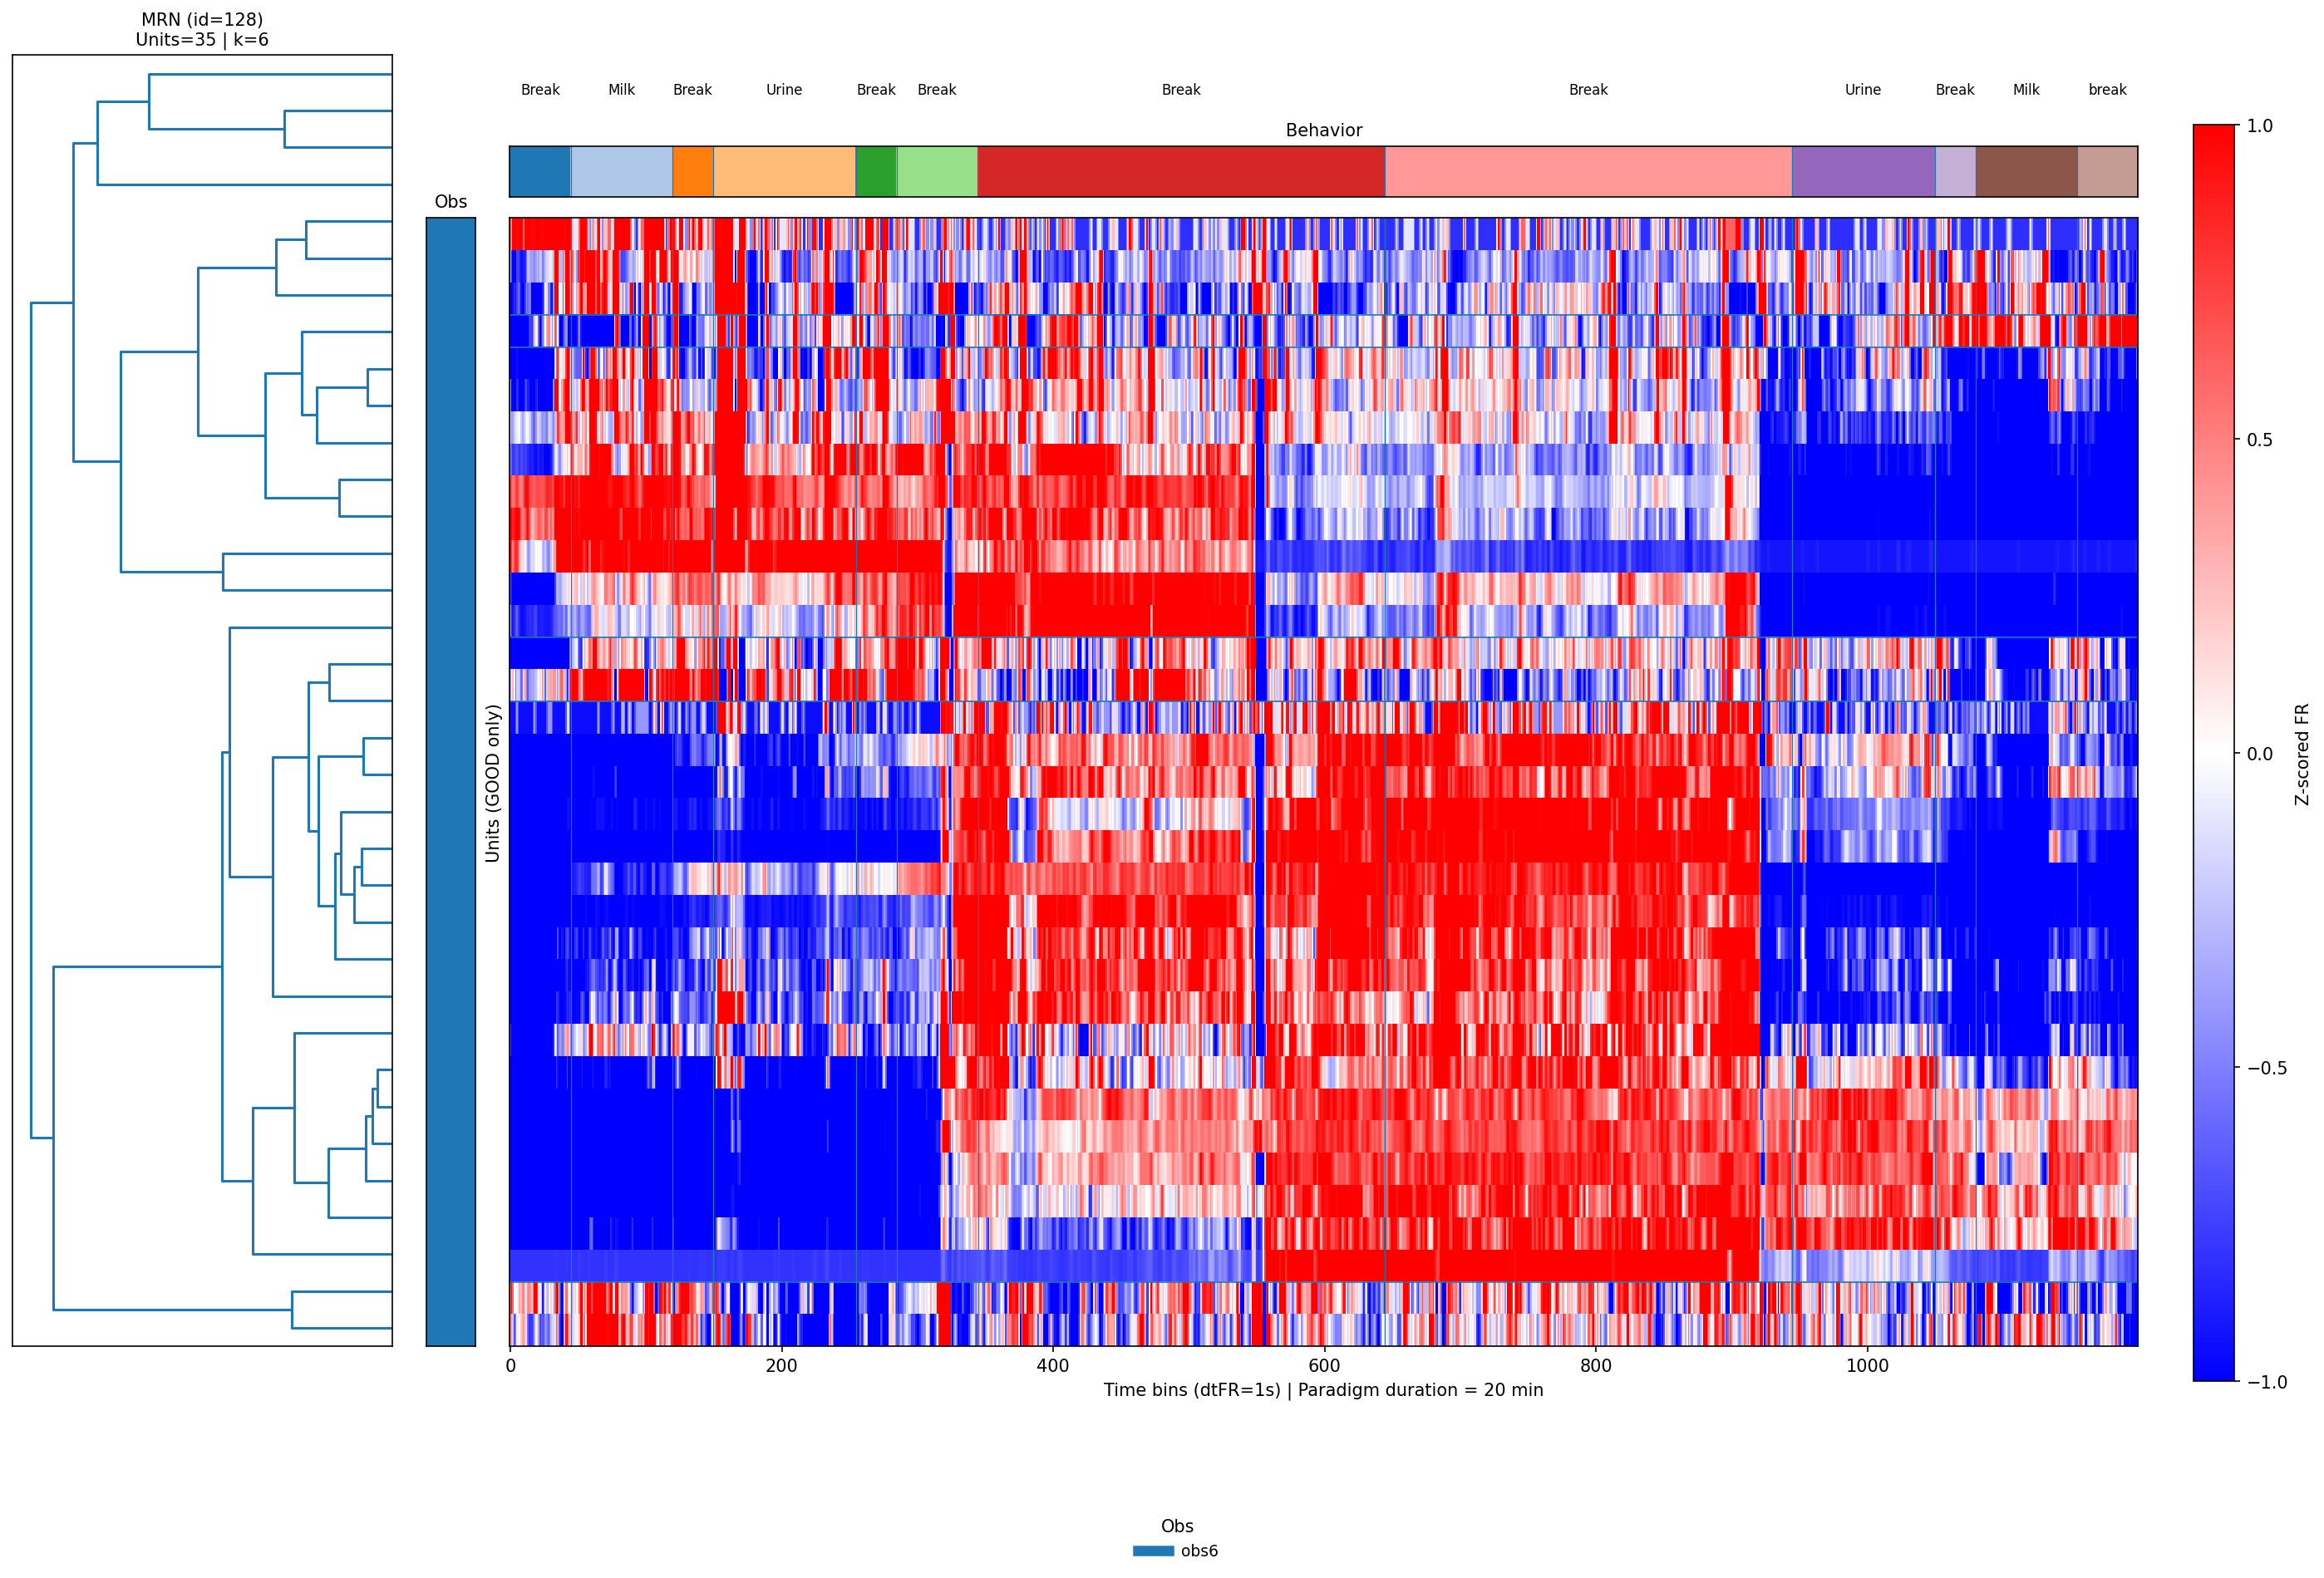

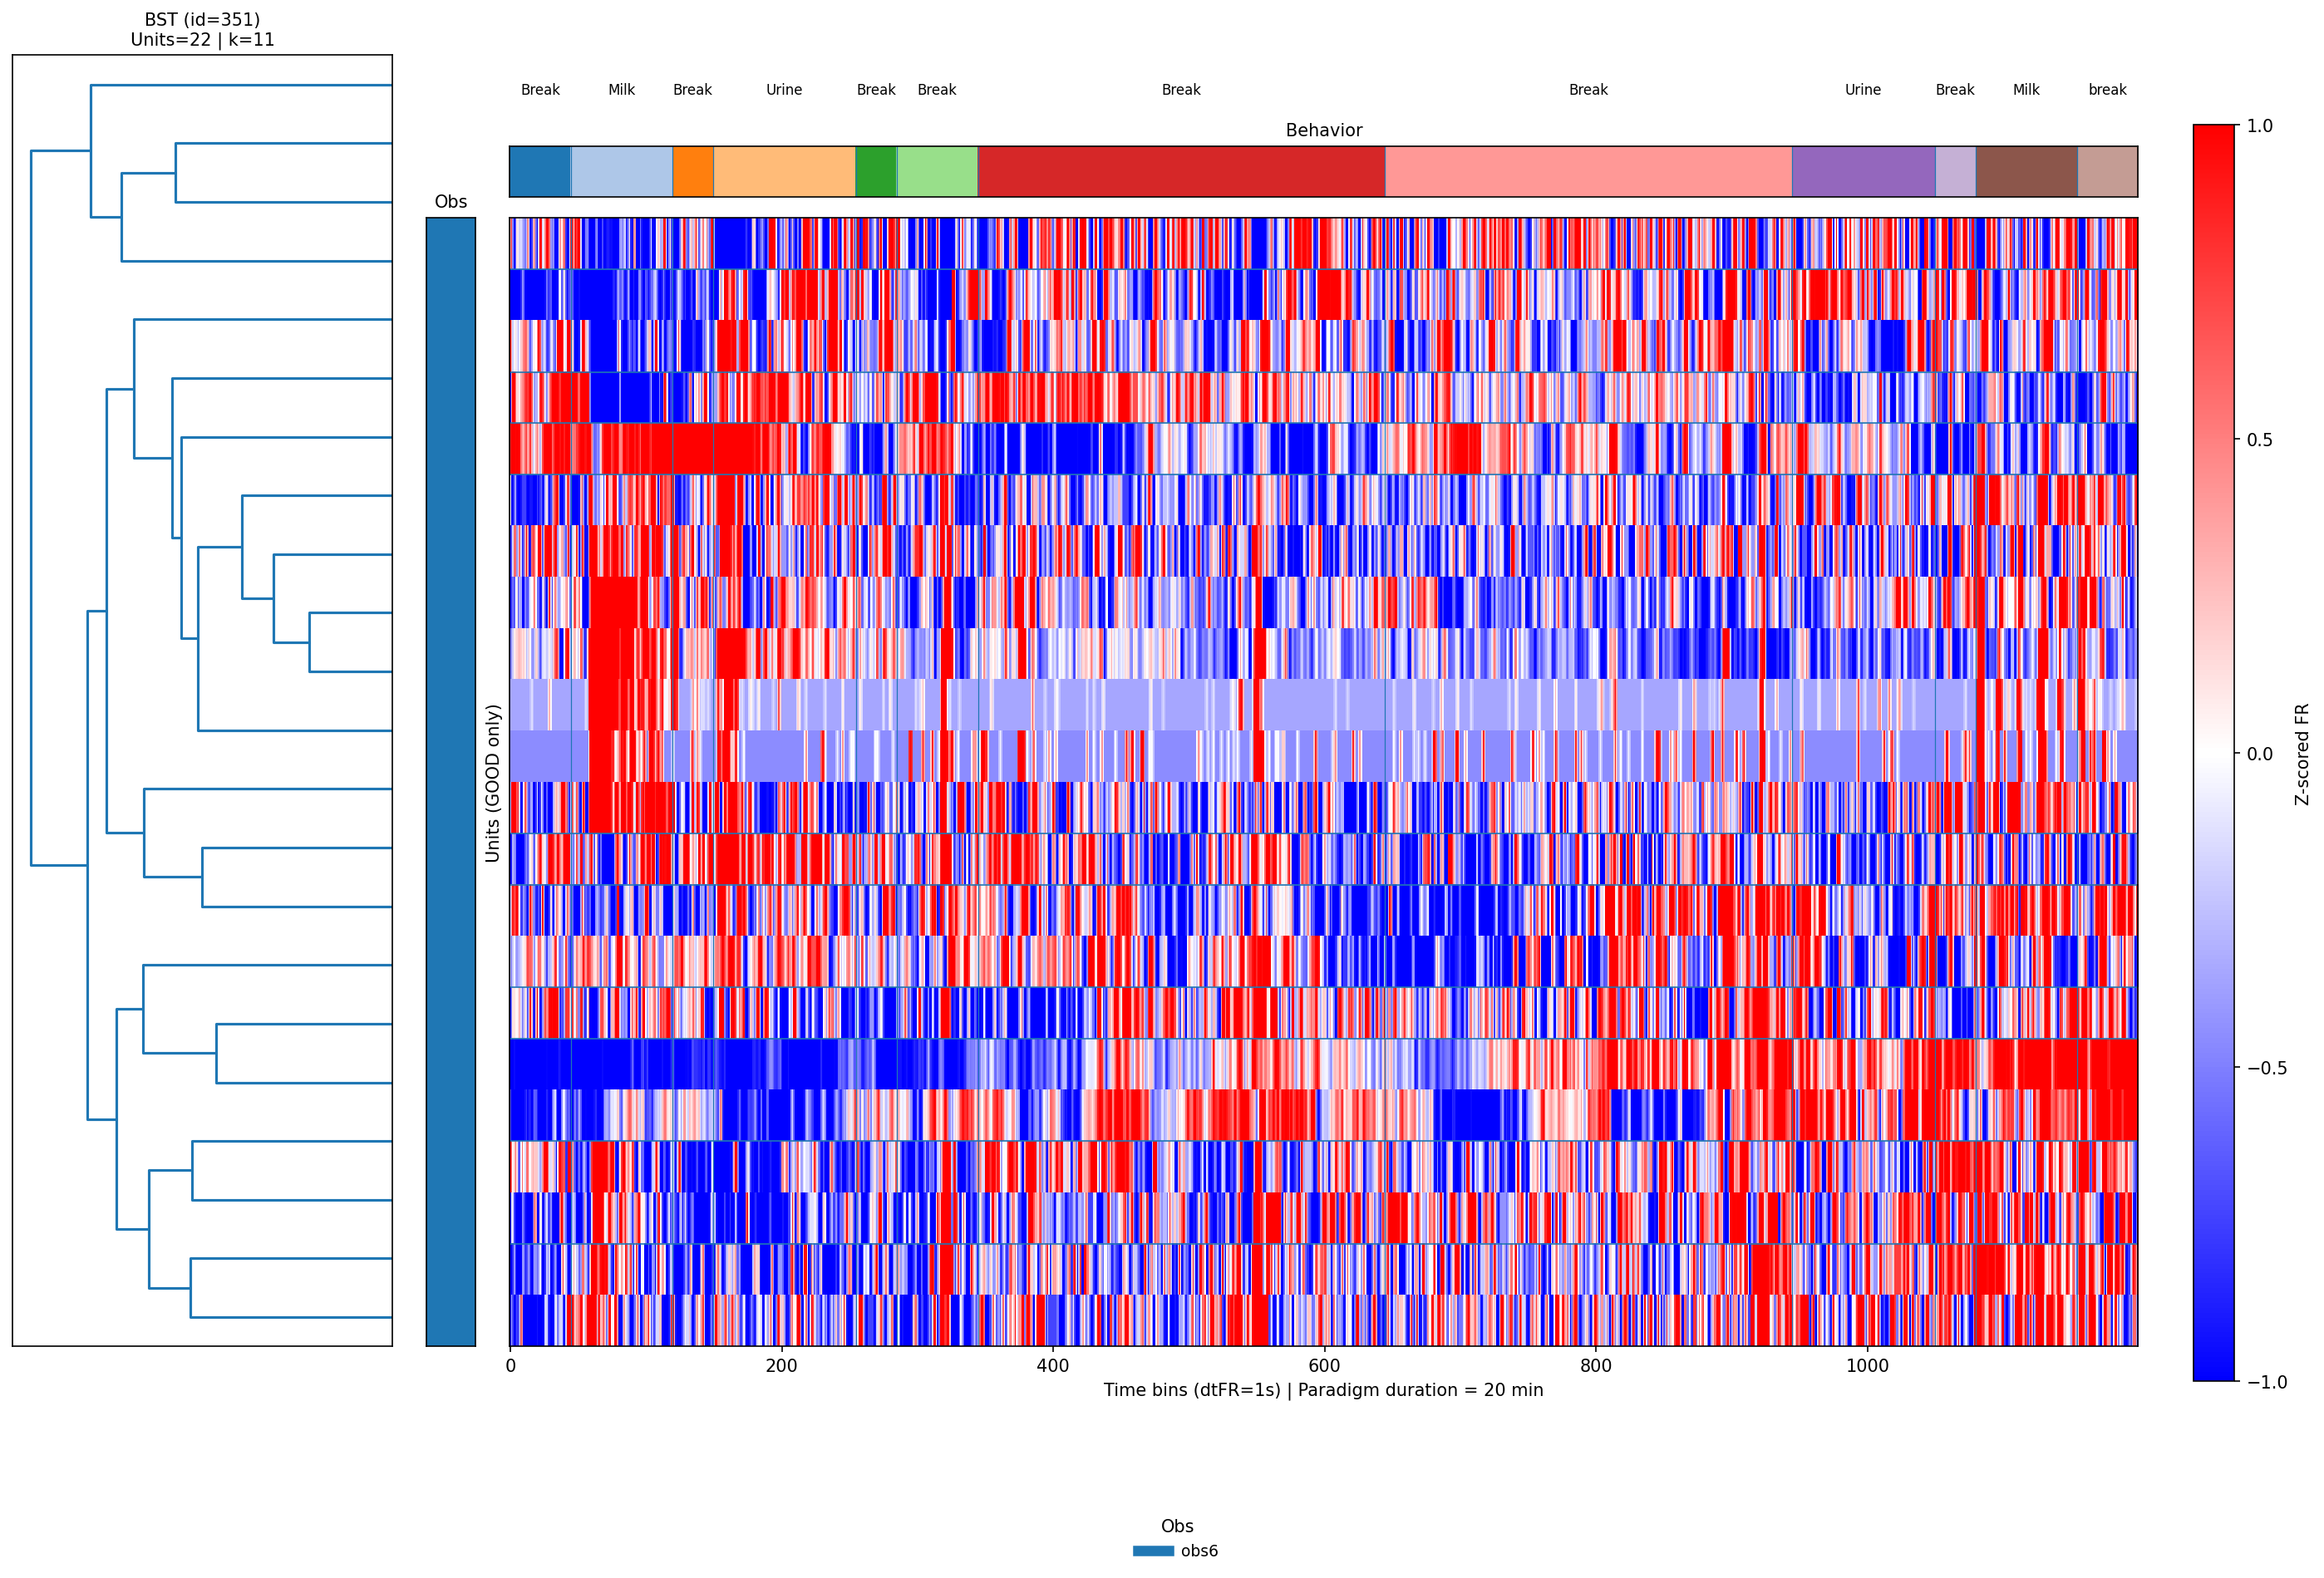

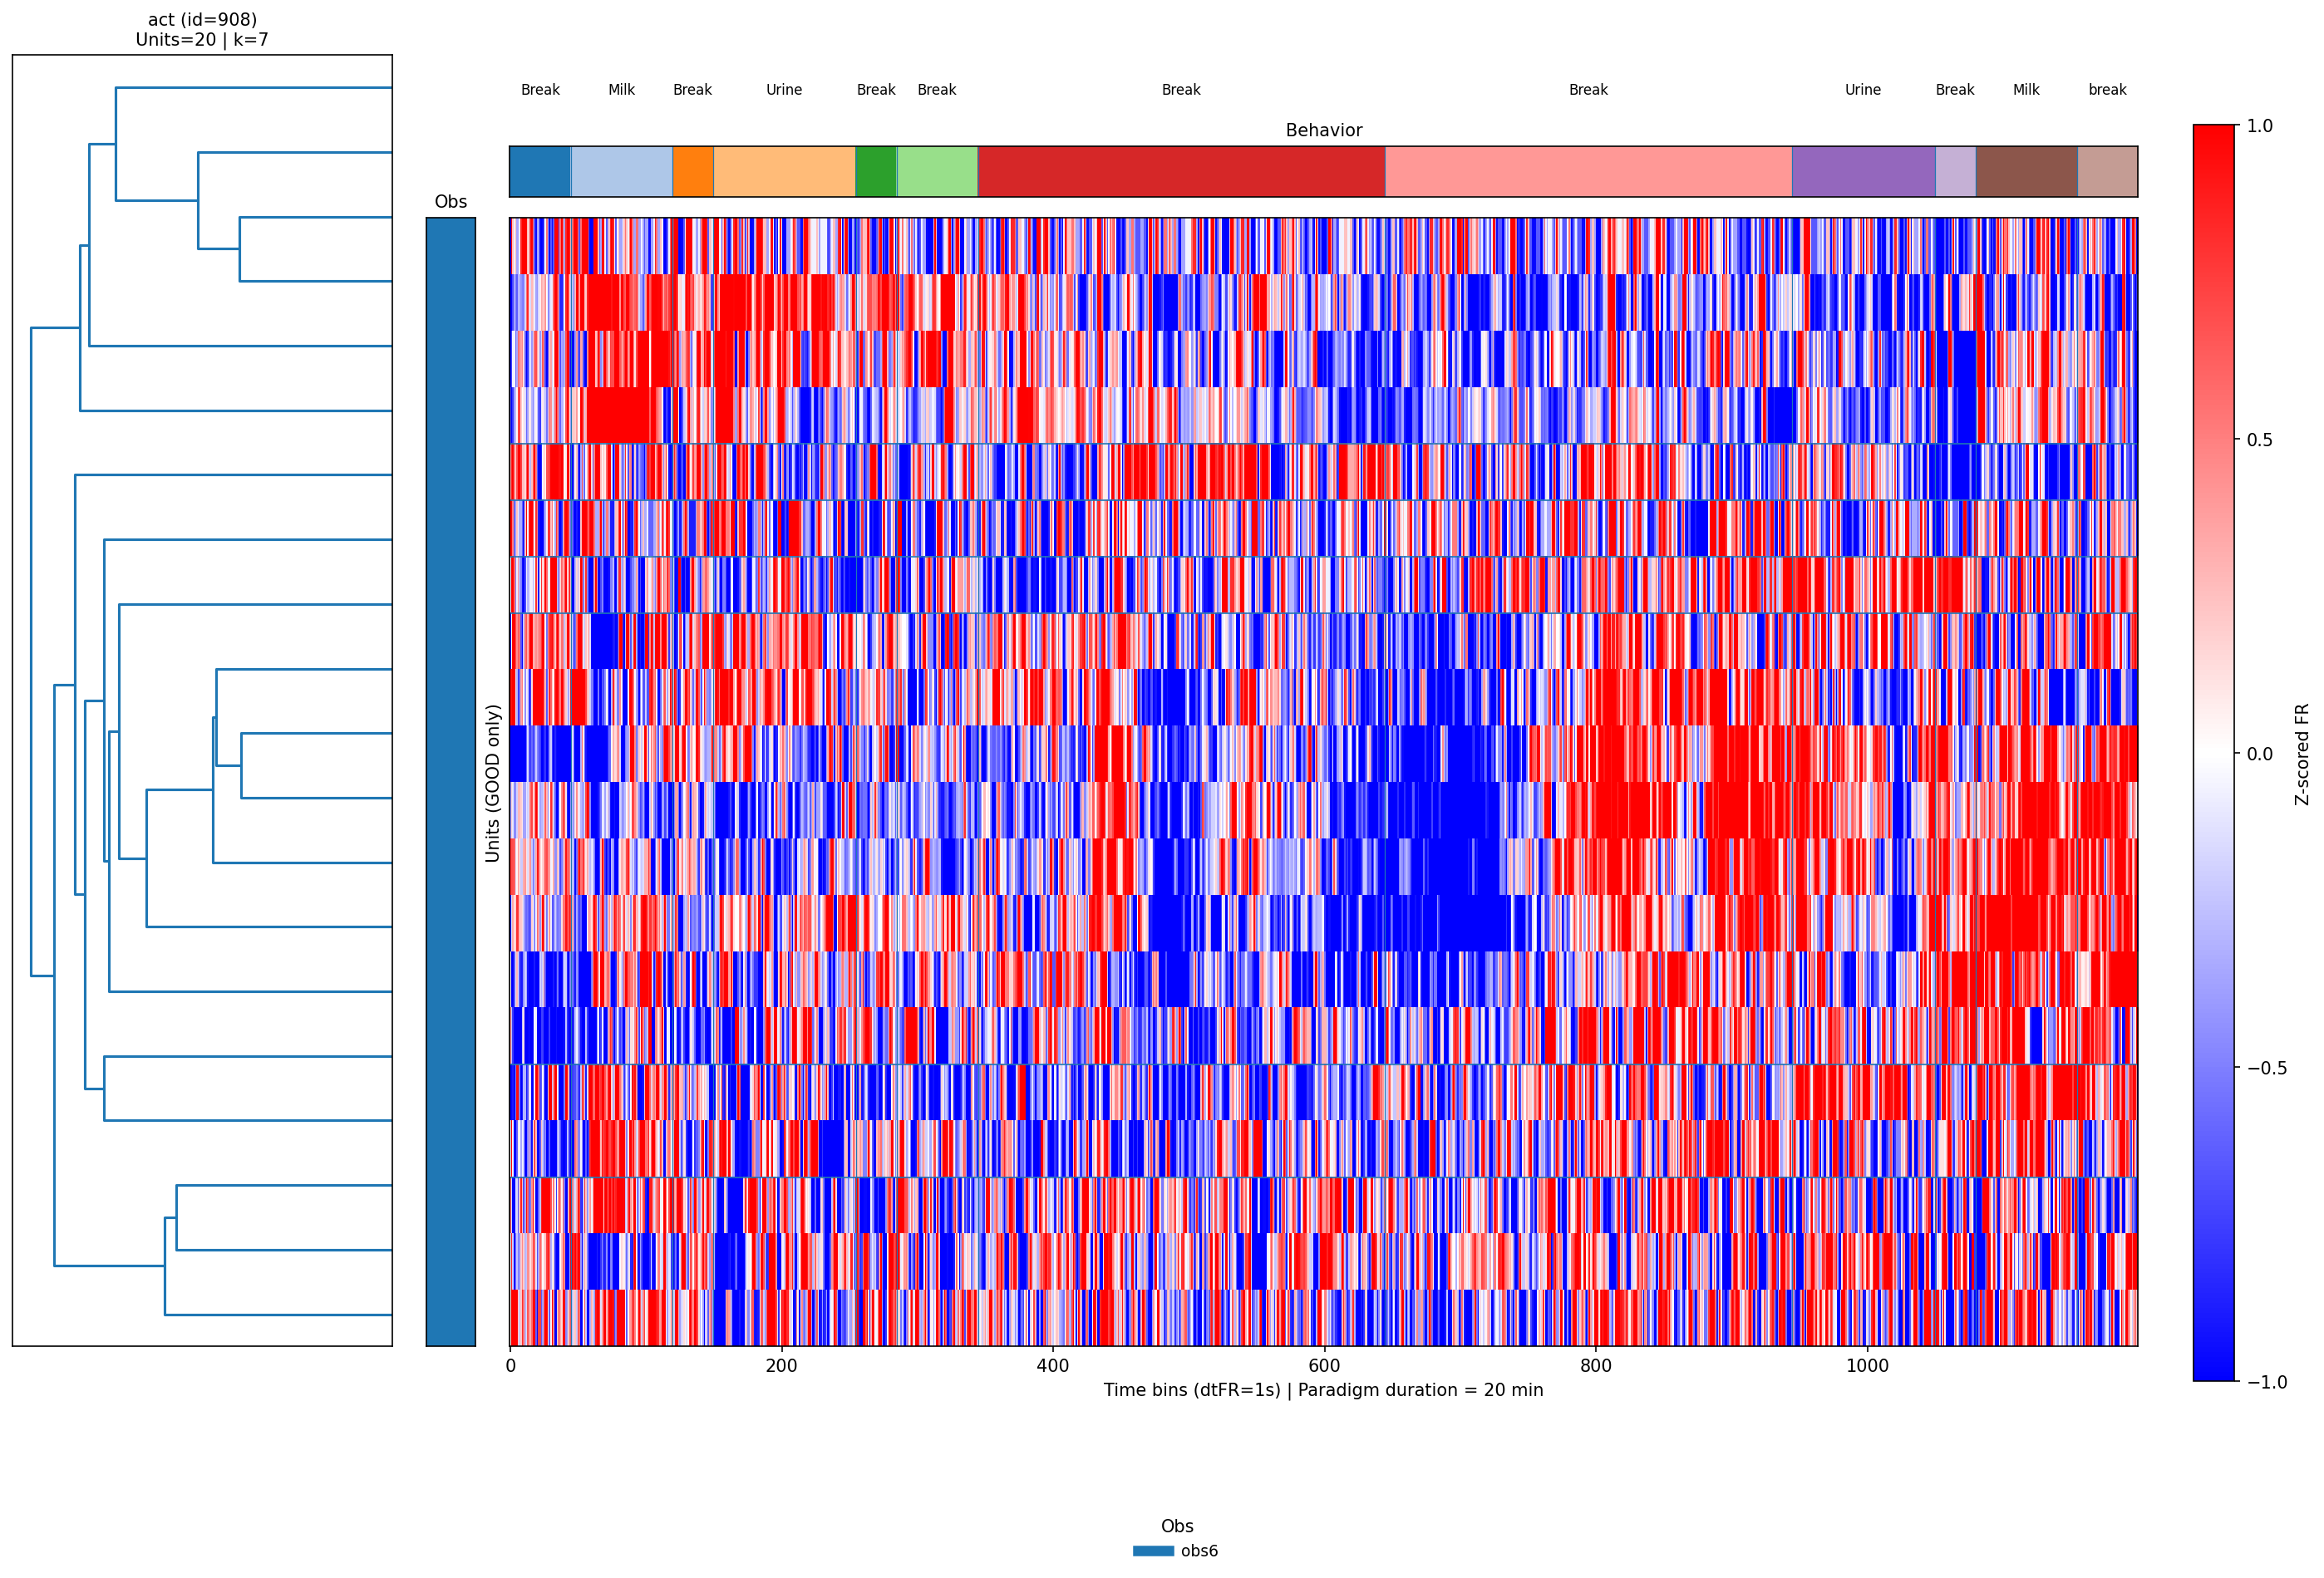

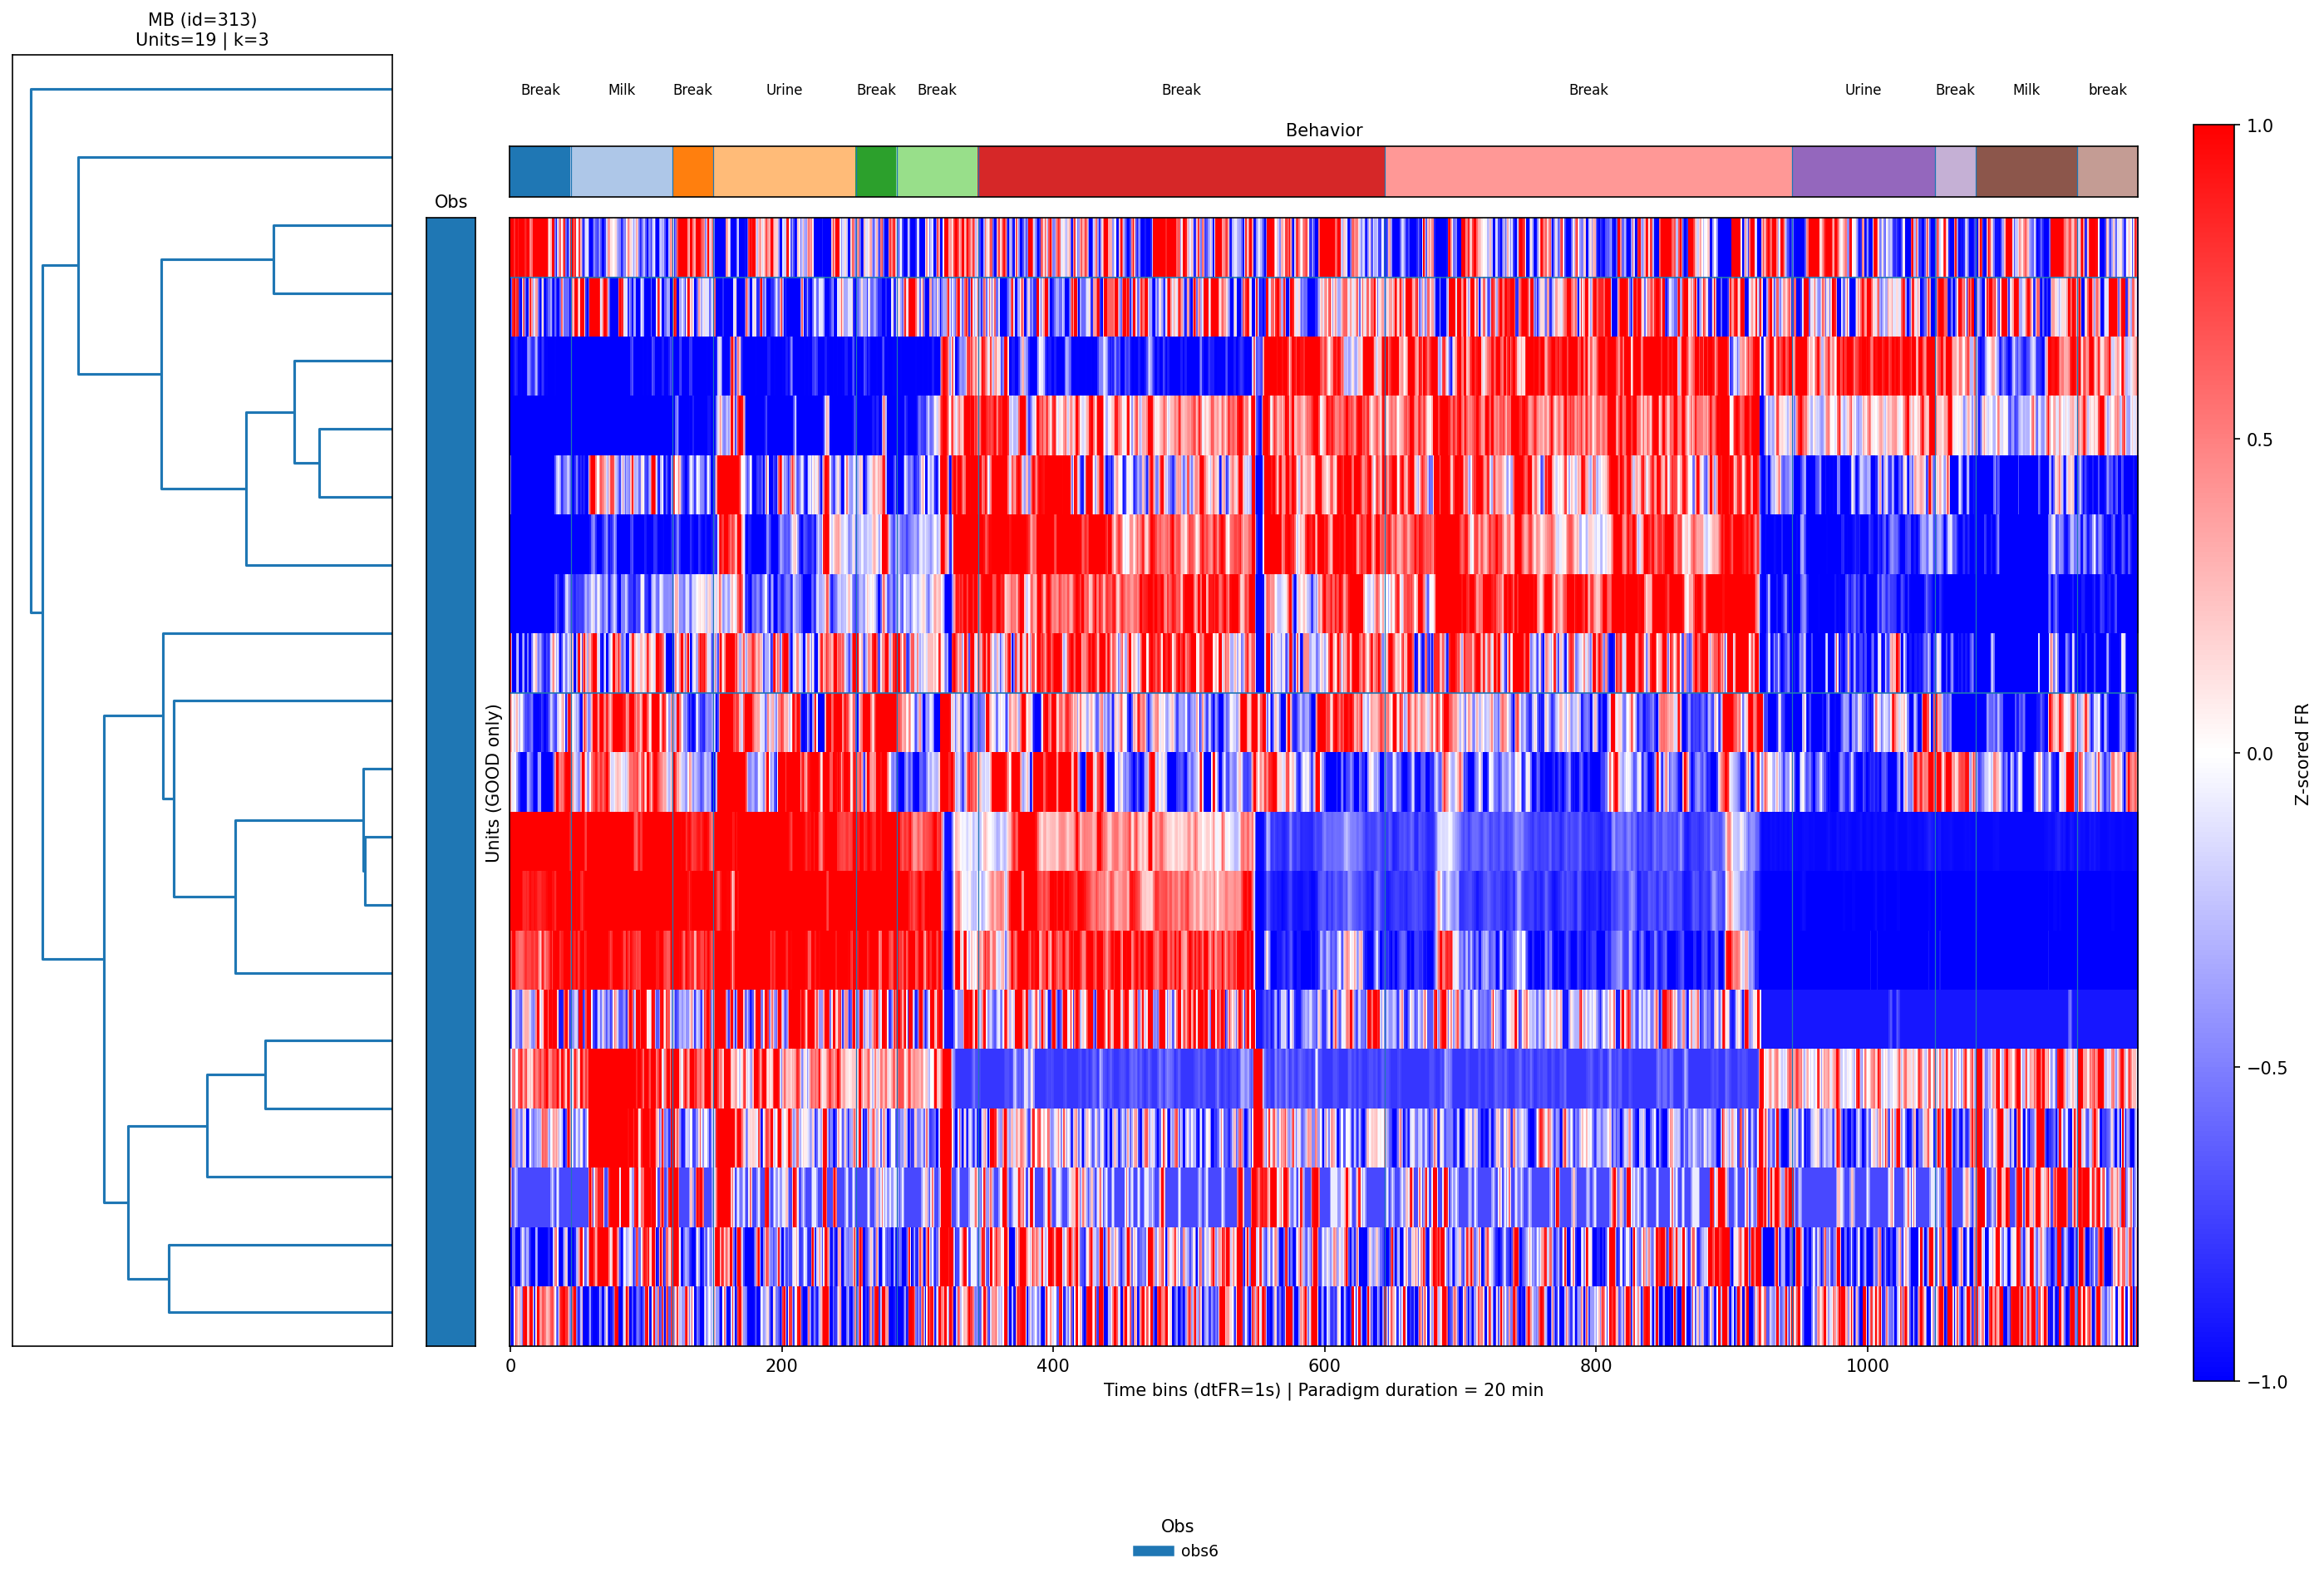

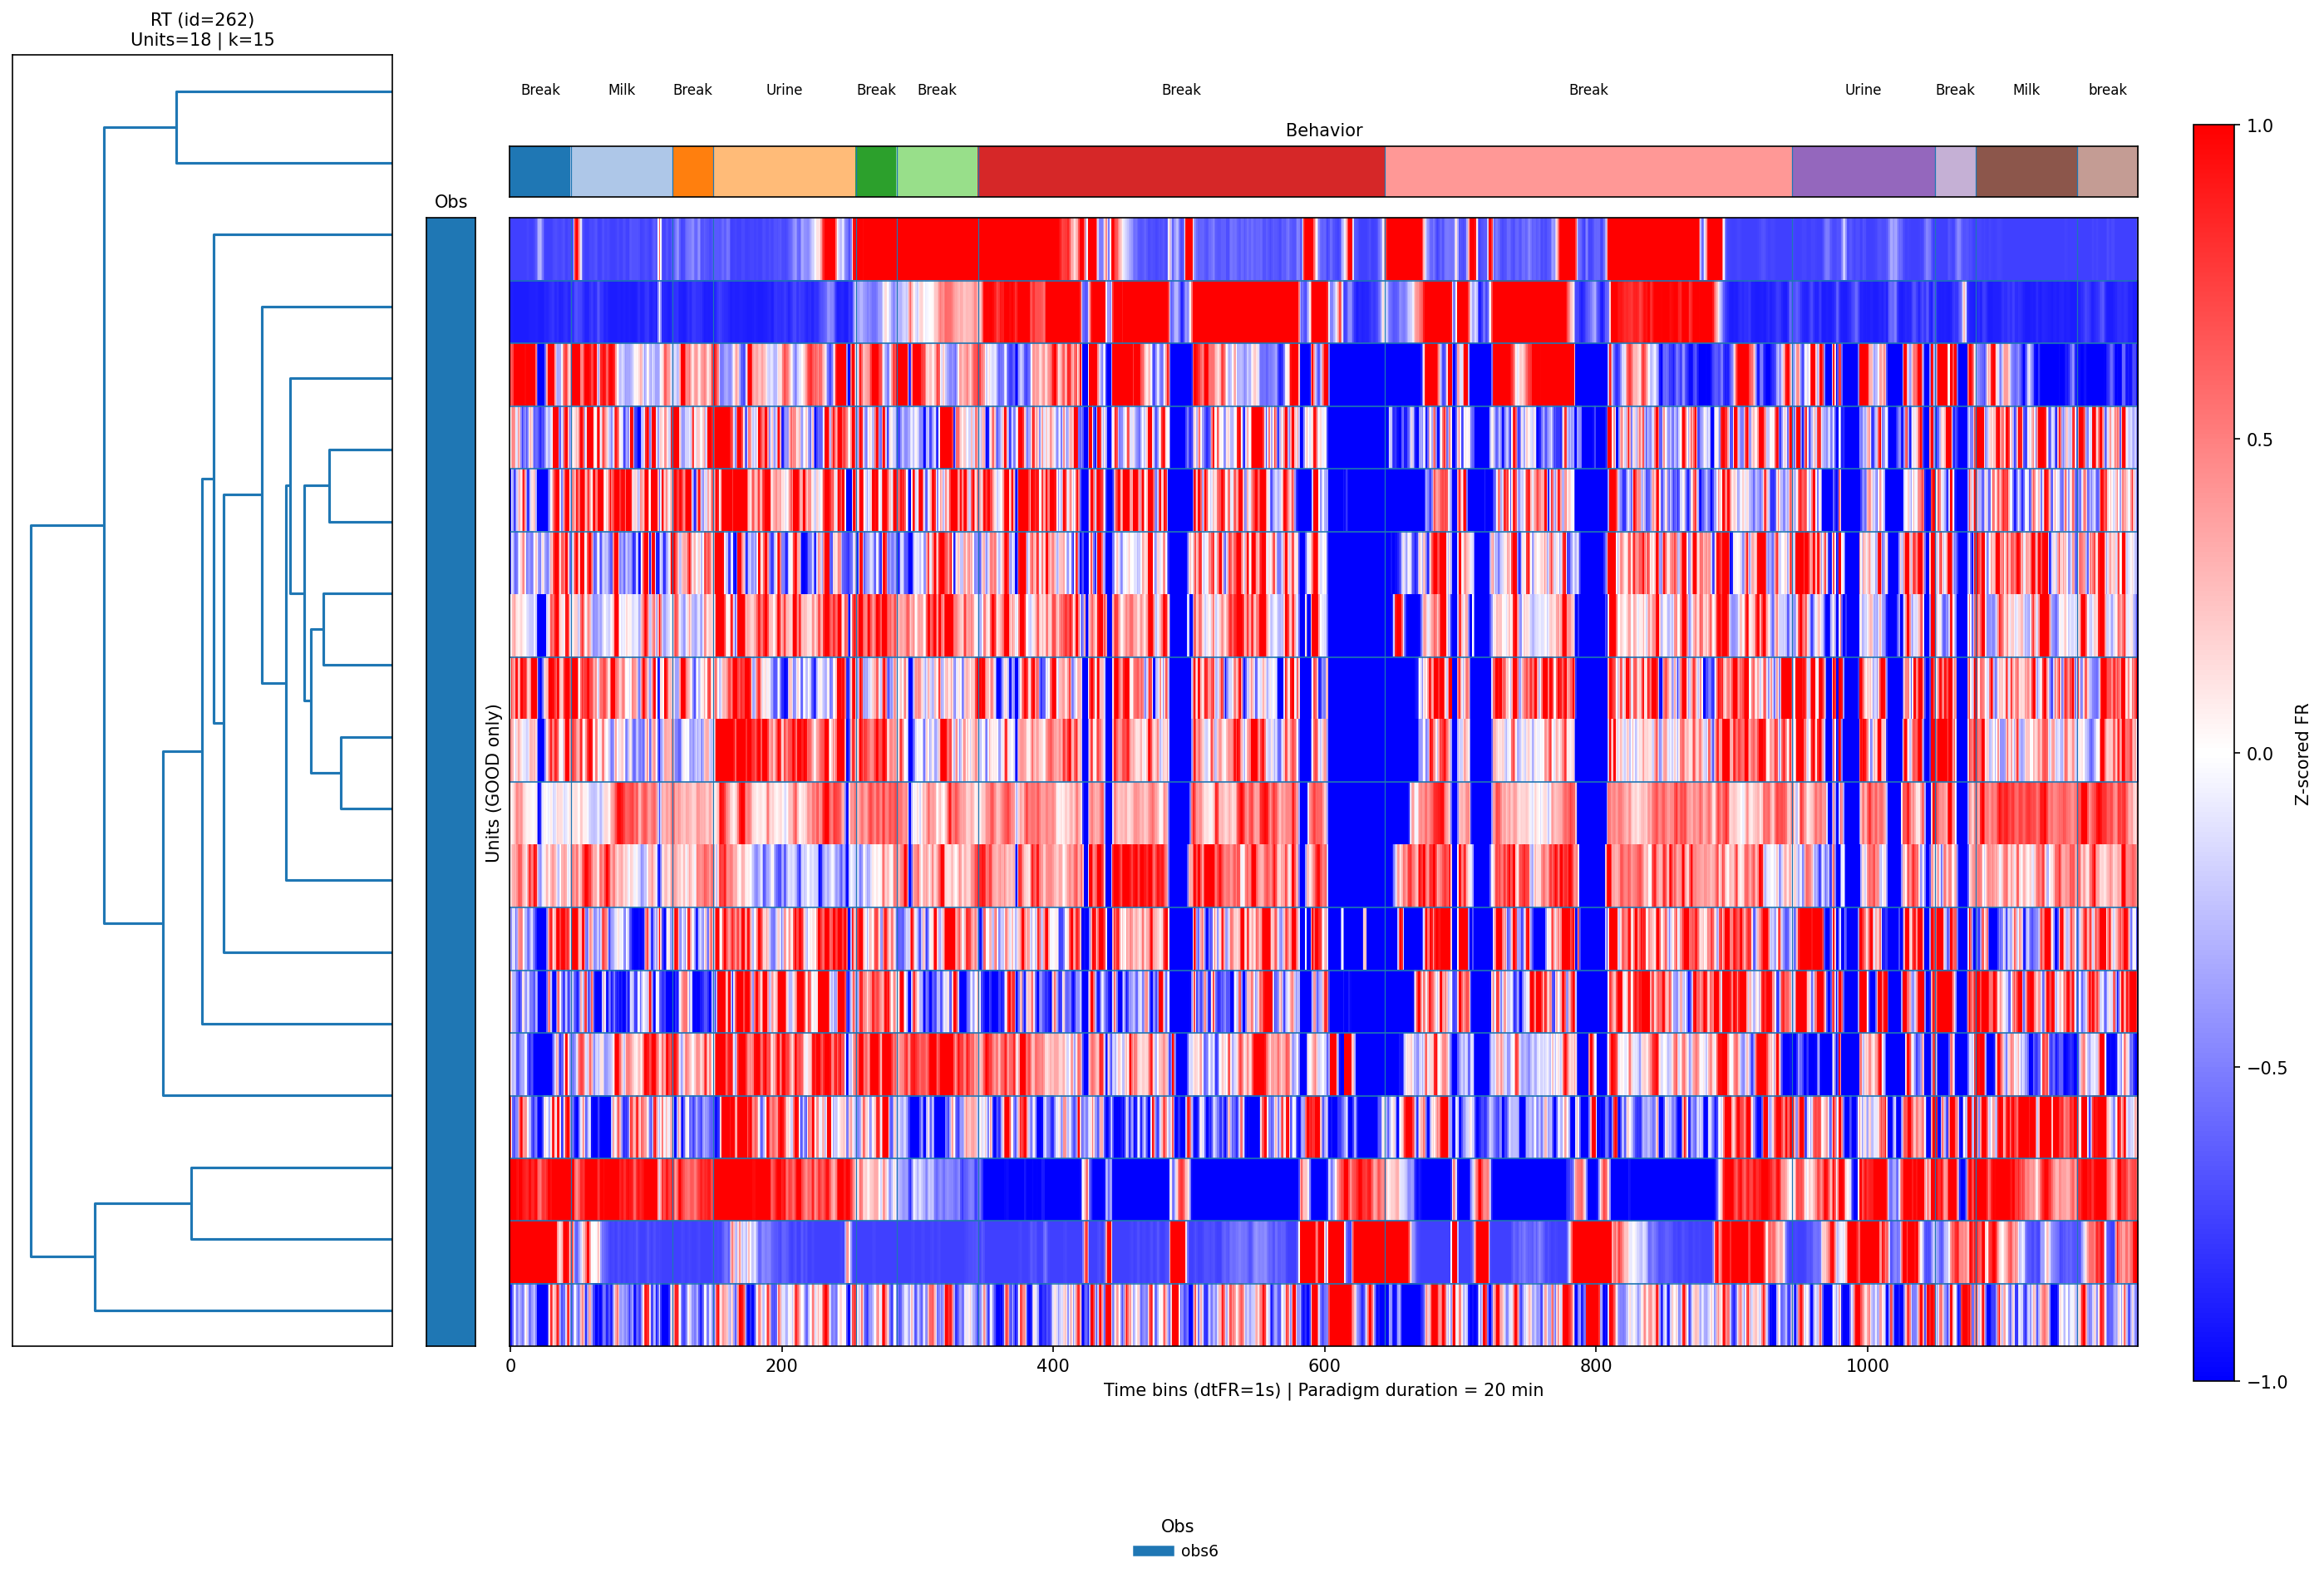

In [527]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from sklearn.metrics import silhouette_samples

# =============================================================================
# ============================= PROCESS 3 SETTINGS ============================
# =============================================================================
MIN_UNITS_PER_REGION = 15   # lower this to see more regions (try 10–20)
MAX_K = 20                  # max clusters tested per region
PLOT_MAX_REGIONS = None     # set int to limit plots, e.g. 20
DROP_UNKNOWN = True         # drop region_ids not present in HERBS region_label lists
DROP_IDS_EXTRA = {0}        # also drop these explicitly (0 often means background)
dtFR = 1

# =============================================================================
# ============================= SANITY CHECKS =================================
# =============================================================================
required = ["frZ", "aligned", "unit_obs", "unit_cluster", "unit_probe", "unit_ksdir",
            "behavSeq", "epochDurSec", "dtFR", "TOTAL_SEC", "HERBS_PROBE_PLK"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables for Process 3: {missing}")

nUnits, nBins = frZ.shape
if not (len(unit_obs) == len(unit_cluster) == len(unit_probe) == len(unit_ksdir) == nUnits):
    raise RuntimeError("unit_* lists must match frZ rows exactly.")

need_cols = {"ks_dir", "probe", "cluster_id", "region_id"}
if not need_cols.issubset(set(aligned.columns)):
    raise RuntimeError(f"`aligned` must contain columns: {sorted(need_cols)}")

# =============================================================================
# ============ 1) Build (ks_dir,probe,cluster_id)->region_id lookup ============
# =============================================================================
region_lookup = {}
for r in aligned.itertuples(index=False):
    key = (str(r.ks_dir), str(r.probe), int(r.cluster_id))
    # keep first occurrence
    if key not in region_lookup:
        region_lookup[key] = int(r.region_id)

print(f"[Process 3] region_lookup entries: {len(region_lookup)}")

unit_region = np.full(nUnits, -1, dtype=np.int64)
for i in range(nUnits):
    key = (str(unit_ksdir[i]), str(unit_probe[i]), int(unit_cluster[i]))
    unit_region[i] = region_lookup.get(key, -1)

print(f"[Process 3] Units total: {nUnits}")
print(f"[Process 3] Units missing region (-1): {int(np.sum(unit_region == -1))}")

# =============================================================================
# ======= 2) Build region_id -> acronym mapping from HERBS probe pkl ===========
# =============================================================================
# We'll build a GLOBAL mapping (region_id -> acronym) by combining all probes.
# Also collect the set of "valid region IDs" from HERBS (region_label).
region_id_to_acr = {}
valid_region_ids = set()

for probe, pkl_path in HERBS_PROBE_PLK.items():
    with open(pkl_path, "rb") as f:
        pobj = pickle.load(f)
    d = pobj["data"]

    # These are lists in your inspection
    region_label = np.asarray(d.get("region_label", []), dtype=np.int64).ravel()
    label_acronym = np.asarray(d.get("label_acronym", []))

    # populate valid ids
    for rid in region_label:
        valid_region_ids.add(int(rid))

    # map each region_label entry to acronym if lengths match
    # If mismatch, just skip mapping for safety
    if len(region_label) == len(label_acronym):
        for rid, acr in zip(region_label, label_acronym):
            rid = int(rid)
            if rid not in region_id_to_acr:
                region_id_to_acr[rid] = str(acr)
    else:
        print(f"[WARN] {probe}: region_label len={len(region_label)} != label_acronym len={len(label_acronym)}")

print(f"[Process 3] region_id_to_acr entries: {len(region_id_to_acr)}")
print(f"[Process 3] valid_region_ids size: {len(valid_region_ids)}")

def region_label_string(rid: int) -> str:
    if rid in region_id_to_acr:
        return f"{region_id_to_acr[rid]} (id={rid})"
    return f"id={rid}"

# =============================================================================
# ======= 3) Clean/filter region IDs (drop bogus huge ints etc.) ===============
# =============================================================================
mask_keep = np.ones(nUnits, dtype=bool)

# drop missing
mask_keep &= (unit_region != -1)

# drop explicit extras
if DROP_IDS_EXTRA:
    mask_keep &= ~np.isin(unit_region, list(DROP_IDS_EXTRA))

# drop unknown IDs not in HERBS region_label lists
if DROP_UNKNOWN:
    mask_keep &= np.isin(unit_region, list(valid_region_ids))

n_kept = int(mask_keep.sum())
print(f"[Process 3] Keeping units after region filtering: {n_kept}/{nUnits}")

frZ2 = frZ[mask_keep, :]
unit_region2 = unit_region[mask_keep]
unit_obs2 = [unit_obs[i] for i in np.where(mask_keep)[0]]

# =============================================================================
# ============================= COLOR MAPS ====================================
# =============================================================================
def make_distinct_colors(n: int):
    if n <= 20:
        return list(plt.get_cmap("tab20").colors[:n])
    cmap = plt.get_cmap("hsv", n)
    return [cmap(i) for i in range(n)]

def colormap_rwb(n: int = 256) -> np.ndarray:
    n2 = n // 2
    blue2white = np.column_stack([np.linspace(0, 1, n2),
                                  np.linspace(0, 1, n2),
                                  np.ones(n2)])
    white2red = np.column_stack([np.ones(n - n2),
                                 np.linspace(1, 0, n - n2),
                                 np.linspace(1, 0, n - n2)])
    return np.vstack([blue2white, white2red])

hm_cmap = plt.matplotlib.colors.ListedColormap(colormap_rwb(256))

# Obs strip coding (stable obs1..obs6)
obs_order = [f"obs{i}" for i in range(1, 7)]
unit_obs_clean = [str(o).strip().lower() for o in unit_obs2]

present_obs = [o for o in obs_order if o in set(unit_obs_clean)]
obs_names = present_obs + sorted(set(unit_obs_clean) - set(obs_order))
obs_to_code = {o: i for i, o in enumerate(obs_names)}
obs_codes_all = np.array([obs_to_code[o] for o in unit_obs_clean], dtype=np.int16)

obs_colors = make_distinct_colors(len(obs_names))
obs_cmap = plt.matplotlib.colors.ListedColormap(obs_colors)

# Behavior bar
behav_colors = make_distinct_colors(len(behavSeq))
behav_cmap = plt.matplotlib.colors.ListedColormap(behav_colors)

behav_codes = np.zeros(nBins, dtype=np.int16)
bin_cursor = 0
for i, dur in enumerate(epochDurSec):
    nb = int(round(dur / dtFR))
    behav_codes[bin_cursor:bin_cursor + nb] = i
    bin_cursor += nb
if bin_cursor != nBins:
    behav_codes = behav_codes[:nBins]

epoch_edges_bins = []
t = 0
for dur in epochDurSec[:-1]:
    t += dur
    epoch_edges_bins.append(int(round(t / dtFR)))

# =============================================================================
# ============================= REGION-WISE CLUSTERING =========================
# =============================================================================
counts = pd.Series(unit_region2).value_counts().sort_values(ascending=False)
print("\n[Process 3] Units per region (top 25):")
for rid, c in counts.head(25).items():
    print(f"  {region_label_string(int(rid))}: {int(c)}")

regions = np.array([rid for rid, c in counts.items() if c >= MIN_UNITS_PER_REGION], dtype=np.int64)
print(f"\n[Process 3] Regions that pass MIN_UNITS_PER_REGION={MIN_UNITS_PER_REGION}: {len(regions)}")

plotted = 0

for region_id in regions:
    idx = np.where(unit_region2 == region_id)[0]
    nU = idx.size
    if nU < 3:
        continue

    X = frZ2[idx, :]

    # clustering
    D = pdist(X, metric="correlation")
    Z = linkage(D, method="average")

    maxK = min(MAX_K, nU - 1)
    avgSil = np.full(maxK + 1, np.nan, dtype=np.float64)
    for k in range(2, maxK + 1):
        ck = fcluster(Z, t=k, criterion="maxclust")
        sil = silhouette_samples(X, ck, metric="correlation")
        avgSil[k] = np.mean(sil)

    dSil = np.diff(avgSil)
    k_best = int(np.nanargmax(dSil[2:]) + 3) if maxK >= 3 else 2

    Z_opt = optimal_leaf_ordering(Z, D)
    dinfo = dendrogram(Z_opt, no_plot=True)
    ord_local = np.array(dinfo["leaves"], dtype=np.int64)

    clu = fcluster(Z_opt, t=k_best, criterion="maxclust")
    clu_reordered = clu[ord_local]
    boundaries = np.where(np.diff(clu_reordered) != 0)[0] + 1

    H = X[ord_local, :]
    obs_strip = obs_codes_all[idx][ord_local]

    # Plot
    fig = plt.figure(figsize=(22, 14), dpi=150)
    gs = fig.add_gridspec(
        nrows=3, ncols=3,
        width_ratios=[1.4, 0.18, 6.0],
        height_ratios=[0.25, 0.18, 4.0],
        wspace=0.05, hspace=0.05
    )

    ax_den = fig.add_subplot(gs[:, 0])
    dendrogram(Z_opt, orientation="left", ax=ax_den, no_labels=True, color_threshold=0)
    ax_den.invert_yaxis()
    ax_den.set_xticks([])
    ax_den.set_yticks([])
    ax_den.set_title(f"{region_label_string(int(region_id))}\nUnits={nU} | k={k_best}", fontsize=10)

    ax_ostrip = fig.add_subplot(gs[2, 1])
    ax_ostrip.imshow(obs_strip[:, None], aspect="auto", interpolation="nearest", cmap=obs_cmap)
    ax_ostrip.set_xticks([])
    ax_ostrip.set_yticks([])
    ax_ostrip.set_title("Obs", fontsize=10)

    ax_beh = fig.add_subplot(gs[1, 2])
    ax_beh.imshow(behav_codes[None, :], aspect="auto", interpolation="nearest", cmap=behav_cmap)
    ax_beh.set_xticks([])
    ax_beh.set_yticks([])
    ax_beh.set_title("Behavior", fontsize=10)

    ax_top = fig.add_subplot(gs[0, 2])
    ax_top.set_xlim(0, nBins)
    ax_top.set_ylim(0, 1)
    ax_top.axis("off")
    start = 0
    for name, dur in zip(behavSeq, epochDurSec):
        end = start + int(round(dur / dtFR))
        cx = (start + end) / 2
        ax_top.text(cx, 0.5, name, ha="center", va="center", fontsize=8)
        start = end

    ax_hm = fig.add_subplot(gs[2, 2])
    im = ax_hm.imshow(H, aspect="auto", interpolation="nearest", cmap=hm_cmap, vmin=-1, vmax=1)
    ax_hm.set_xlabel(f"Time bins (dtFR={dtFR}s) | Paradigm duration = {int(TOTAL_SEC/60)} min")
    ax_hm.set_ylabel("Units (GOOD only)")
    ax_hm.set_yticks([])

    for b in boundaries:
        ax_hm.axhline(b - 0.5, linewidth=0.8)
        ax_ostrip.axhline(b - 0.5, linewidth=0.8)

    for xb in epoch_edges_bins:
        ax_hm.axvline(xb - 0.5, linewidth=0.6)
        ax_beh.axvline(xb - 0.5, linewidth=0.6)

    cax = fig.add_axes([0.92, 0.12, 0.015, 0.72])
    cb = fig.colorbar(im, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
    cb.set_label("Z-scored FR")

    handles_obs = [plt.Line2D([0], [0], color=obs_colors[i], lw=6) for i in range(len(obs_names))]
    fig.legend(handles_obs, obs_names,
               loc="lower center",
               bbox_to_anchor=(0.55, 0.01),
               ncol=min(6, len(obs_names)),
               frameon=False,
               fontsize=9,
               title="Obs")

    fig.subplots_adjust(bottom=0.14)
    plt.show()

    plotted += 1
    if PLOT_MAX_REGIONS is not None and plotted >= int(PLOT_MAX_REGIONS):
        break


In [528]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from sklearn.metrics import silhouette_samples

# =============================================================================
# ============================= PROCESS 3b SETTINGS ============================
# =============================================================================
MAX_K = 20                       # max clusters tested (global)
DROP_UNKNOWN = True              # drop region_ids not present in HERBS region_label lists
DROP_IDS_EXTRA = {0}             # drop these explicitly (0 often background)

TOP_N_REGIONS_FOR_CLUSTERING = 10     # restrict clustering to top N regions by UNIT COUNT (set None to disable)
SHOW_TOP_N_REGION_LEGEND = 10         # legend can get big; show top N by count

# =============================================================================
# ============================= SANITY CHECKS =================================
# =============================================================================
required = ["frZ", "aligned", "unit_obs", "unit_cluster", "unit_probe", "unit_ksdir",
            "behavSeq", "epochDurSec", "dtFR", "TOTAL_SEC", "HERBS_PROBE_PLK"]
missing = [x for x in required if x not in globals()]
if missing:
    raise RuntimeError(f"Missing required variables for Process 3b: {missing}")

nUnits, nBins = frZ.shape
if not (len(unit_obs) == len(unit_cluster) == len(unit_probe) == len(unit_ksdir) == nUnits):
    raise RuntimeError("unit_* lists must match frZ rows exactly.")

need_cols = {"ks_dir", "probe", "cluster_id", "region_id"}
if not need_cols.issubset(set(aligned.columns)):
    raise RuntimeError(f"`aligned` must contain columns: {sorted(need_cols)}")

# =============================================================================
# ============ 1) Build (ks_dir,probe,cluster_id)->region_id lookup ============
# =============================================================================
region_lookup = {}
for r in aligned.itertuples(index=False):
    key = (str(r.ks_dir), str(r.probe), int(r.cluster_id))
    if key not in region_lookup:
        region_lookup[key] = int(r.region_id)

unit_region = np.full(nUnits, -1, dtype=np.int64)
for i in range(nUnits):
    key = (str(unit_ksdir[i]), str(unit_probe[i]), int(unit_cluster[i]))
    unit_region[i] = region_lookup.get(key, -1)

print(f"[Process 3b] Units total: {nUnits}")
print(f"[Process 3b] Units missing region (-1): {int(np.sum(unit_region == -1))}")

# =============================================================================
# ======= 2) Build region_id -> acronym/fullname mapping from HERBS pkls =======
# =============================================================================
region_id_to_acr = {}
region_id_to_name = {}
valid_region_ids = set()

for probe, pkl_path in HERBS_PROBE_PLK.items():
    with open(pkl_path, "rb") as f:
        pobj = pickle.load(f)
    d = pobj["data"]

    region_label = np.asarray(d.get("region_label", []), dtype=np.int64).ravel()
    label_acronym = np.asarray(d.get("label_acronym", []))
    label_name = np.asarray(d.get("label_name", []))

    for rid in region_label:
        valid_region_ids.add(int(rid))

    # Map id -> acronym/name if lengths match
    if len(region_label) == len(label_acronym):
        for rid, acr in zip(region_label, label_acronym):
            rid = int(rid)
            if rid not in region_id_to_acr:
                region_id_to_acr[rid] = str(acr)
    else:
        print(f"[WARN] {probe}: region_label len={len(region_label)} != label_acronym len={len(label_acronym)}")

    if len(region_label) == len(label_name):
        for rid, nm in zip(region_label, label_name):
            rid = int(rid)
            if rid not in region_id_to_name:
                region_id_to_name[rid] = str(nm)
    else:
        print(f"[WARN] {probe}: region_label len={len(region_label)} != label_name len={len(label_name)}")

def region_label_string(rid: int) -> str:
    acr = region_id_to_acr.get(rid, "")
    nm = region_id_to_name.get(rid, "")
    if acr and nm:
        return f"{acr} — {nm} (id={rid})"
    if acr:
        return f"{acr} (id={rid})"
    if nm:
        return f"{nm} (id={rid})"
    return f"id={rid}"

print(f"[Process 3b] region_id_to_acr entries: {len(region_id_to_acr)}")
print(f"[Process 3b] region_id_to_name entries: {len(region_id_to_name)}")
print(f"[Process 3b] valid_region_ids size: {len(valid_region_ids)}")

# =============================================================================
# ======= 3) Filter units by region validity (same idea as your Process 3) =====
# =============================================================================
mask_keep = np.ones(nUnits, dtype=bool)

mask_keep &= (unit_region != -1)
if DROP_IDS_EXTRA:
    mask_keep &= ~np.isin(unit_region, list(DROP_IDS_EXTRA))
if DROP_UNKNOWN:
    mask_keep &= np.isin(unit_region, list(valid_region_ids))

keep_idx = np.where(mask_keep)[0]
print(f"[Process 3b] Keeping units after region filtering: {len(keep_idx)}/{nUnits}")

frZ2 = frZ[keep_idx, :]
unit_region2 = unit_region[keep_idx]
unit_obs2 = [unit_obs[i] for i in keep_idx]

nUnits2 = frZ2.shape[0]
if nUnits2 < 3:
    raise RuntimeError("Not enough units after filtering to cluster.")

# =============================================================================
# ======= 3.5) Restrict clustering to TOP-N regions (by unit count) ============
# =============================================================================
if TOP_N_REGIONS_FOR_CLUSTERING is not None:
    region_counts0 = pd.Series(unit_region2).value_counts()
    top_regions = region_counts0.index[:TOP_N_REGIONS_FOR_CLUSTERING].astype(int).to_numpy()

    mask_top = np.isin(unit_region2, top_regions)

    print(f"\n[Process 3b] Restricting clustering to top {TOP_N_REGIONS_FOR_CLUSTERING} regions by unit count:")
    for rid, c in region_counts0.loc[top_regions].items():
        print(f"  {region_label_string(int(rid))}: {int(c)}")

    frZ2 = frZ2[mask_top, :]
    unit_region2 = unit_region2[mask_top]
    unit_obs2 = [unit_obs2[i] for i in np.where(mask_top)[0]]

    nUnits2 = frZ2.shape[0]
    print(f"[Process 3b] Units after TOP-N region restriction: {nUnits2}")

    if nUnits2 < 3:
        raise RuntimeError("Not enough units after restricting to top regions.")

# =============================================================================
# ============================= COLOR MAPS ====================================
# =============================================================================
def make_distinct_colors(n: int):
    if n <= 20:
        return list(plt.get_cmap("tab20").colors[:n])
    cmap = plt.get_cmap("hsv", n)
    return [cmap(i) for i in range(n)]

def colormap_rwb(n: int = 256) -> np.ndarray:
    n2 = n // 2
    blue2white = np.column_stack([np.linspace(0, 1, n2),
                                  np.linspace(0, 1, n2),
                                  np.ones(n2)])
    white2red = np.column_stack([np.ones(n - n2),
                                 np.linspace(1, 0, n - n2),
                                 np.linspace(1, 0, n - n2)])
    return np.vstack([blue2white, white2red])

hm_cmap = plt.matplotlib.colors.ListedColormap(colormap_rwb(256))

# Obs strip coding (stable obs1..obs6)
obs_order = [f"obs{i}" for i in range(1, 7)]
unit_obs_clean = [str(o).strip().lower() for o in unit_obs2]
present_obs = [o for o in obs_order if o in set(unit_obs_clean)]
obs_names = present_obs + sorted(set(unit_obs_clean) - set(obs_order))
obs_to_code = {o: i for i, o in enumerate(obs_names)}
obs_codes_all = np.array([obs_to_code[o] for o in unit_obs_clean], dtype=np.int16)

obs_colors = make_distinct_colors(len(obs_names))
obs_cmap = plt.matplotlib.colors.ListedColormap(obs_colors)

# Region strip coding (stable by descending count)
region_counts = pd.Series(unit_region2).value_counts()
region_order = list(region_counts.index.astype(int))  # most common first
region_to_code = {rid: i for i, rid in enumerate(region_order)}
region_codes_all = np.array([region_to_code[int(rid)] for rid in unit_region2], dtype=np.int32)

region_colors = make_distinct_colors(len(region_order))
region_cmap = plt.matplotlib.colors.ListedColormap(region_colors)

print("\n[Process 3b] Units per region (top 25) — acronym + FULL NAME:")
for rid, c in region_counts.head(25).items():
    print(f"  {region_label_string(int(rid))}: {int(c)}")

# Behavior bar (same as your Process 3)
behav_colors = make_distinct_colors(len(behavSeq))
behav_cmap = plt.matplotlib.colors.ListedColormap(behav_colors)

behav_codes = np.zeros(nBins, dtype=np.int16)
bin_cursor = 0
for i, dur in enumerate(epochDurSec):
    nb = int(round(dur / dtFR))
    behav_codes[bin_cursor:bin_cursor + nb] = i
    bin_cursor += nb
behav_codes = behav_codes[:nBins]

epoch_edges_bins = []
t = 0
for dur in epochDurSec[:-1]:
    t += dur
    epoch_edges_bins.append(int(round(t / dtFR)))

# =============================================================================
# ============================= GLOBAL CLUSTERING =============================
# =============================================================================
X = frZ2  # (units x bins)

D = pdist(X, metric="correlation")
Z = linkage(D, method="average")

maxK = min(MAX_K, nUnits2 - 1)
avgSil = np.full(maxK + 1, np.nan, dtype=np.float64)
for k in range(2, maxK + 1):
    ck = fcluster(Z, t=k, criterion="maxclust")
    sil = silhouette_samples(X, ck, metric="correlation")
    avgSil[k] = np.mean(sil)

dSil = np.diff(avgSil)
k_best = int(np.nanargmax(dSil[2:]) + 3) if maxK >= 3 else 2
print(f"\n[Process 3b] Using global k (elbow) = {k_best}")

Z_opt = optimal_leaf_ordering(Z, D)
dinfo = dendrogram(Z_opt, no_plot=True)
ord_local = np.array(dinfo["leaves"], dtype=np.int64)

clu = fcluster(Z_opt, t=k_best, criterion="maxclust")
clu_reordered = clu[ord_local]
boundaries = np.where(np.diff(clu_reordered) != 0)[0] + 1

H = X[ord_local, :]
obs_strip = obs_codes_all[ord_local]
region_strip = region_codes_all[ord_local]


[Process 3b] Units total: 218
[Process 3b] Units missing region (-1): 0
[Process 3b] region_id_to_acr entries: 59
[Process 3b] region_id_to_name entries: 59
[Process 3b] valid_region_ids size: 59
[Process 3b] Keeping units after region filtering: 218/218

[Process 3b] Restricting clustering to top 10 regions by unit count:
  MRN — Midbrain reticular nucleus (id=128): 35
  BST — Bed nuclei of the stria terminalis (id=351): 22
  act — anterior commissure temporal limb (id=908): 20
  MB — Midbrain (id=313): 19
  RT — Reticular nucleus of the thalamus (id=262): 18
  CP — Caudoputamen (id=672): 14
  PAG — Periaqueductal gray (id=795): 12
  SCdg — Superior colliculus motor related deep gray layer (id=26): 11
  PS — Parastrial nucleus (id=1109): 7
  SCiw — Superior colliculus motor related intermediate white layer (id=17): 6
[Process 3b] Units after TOP-N region restriction: 164

[Process 3b] Units per region (top 25) — acronym + FULL NAME:
  MRN — Midbrain reticular nucleus (id=128): 35
  BS

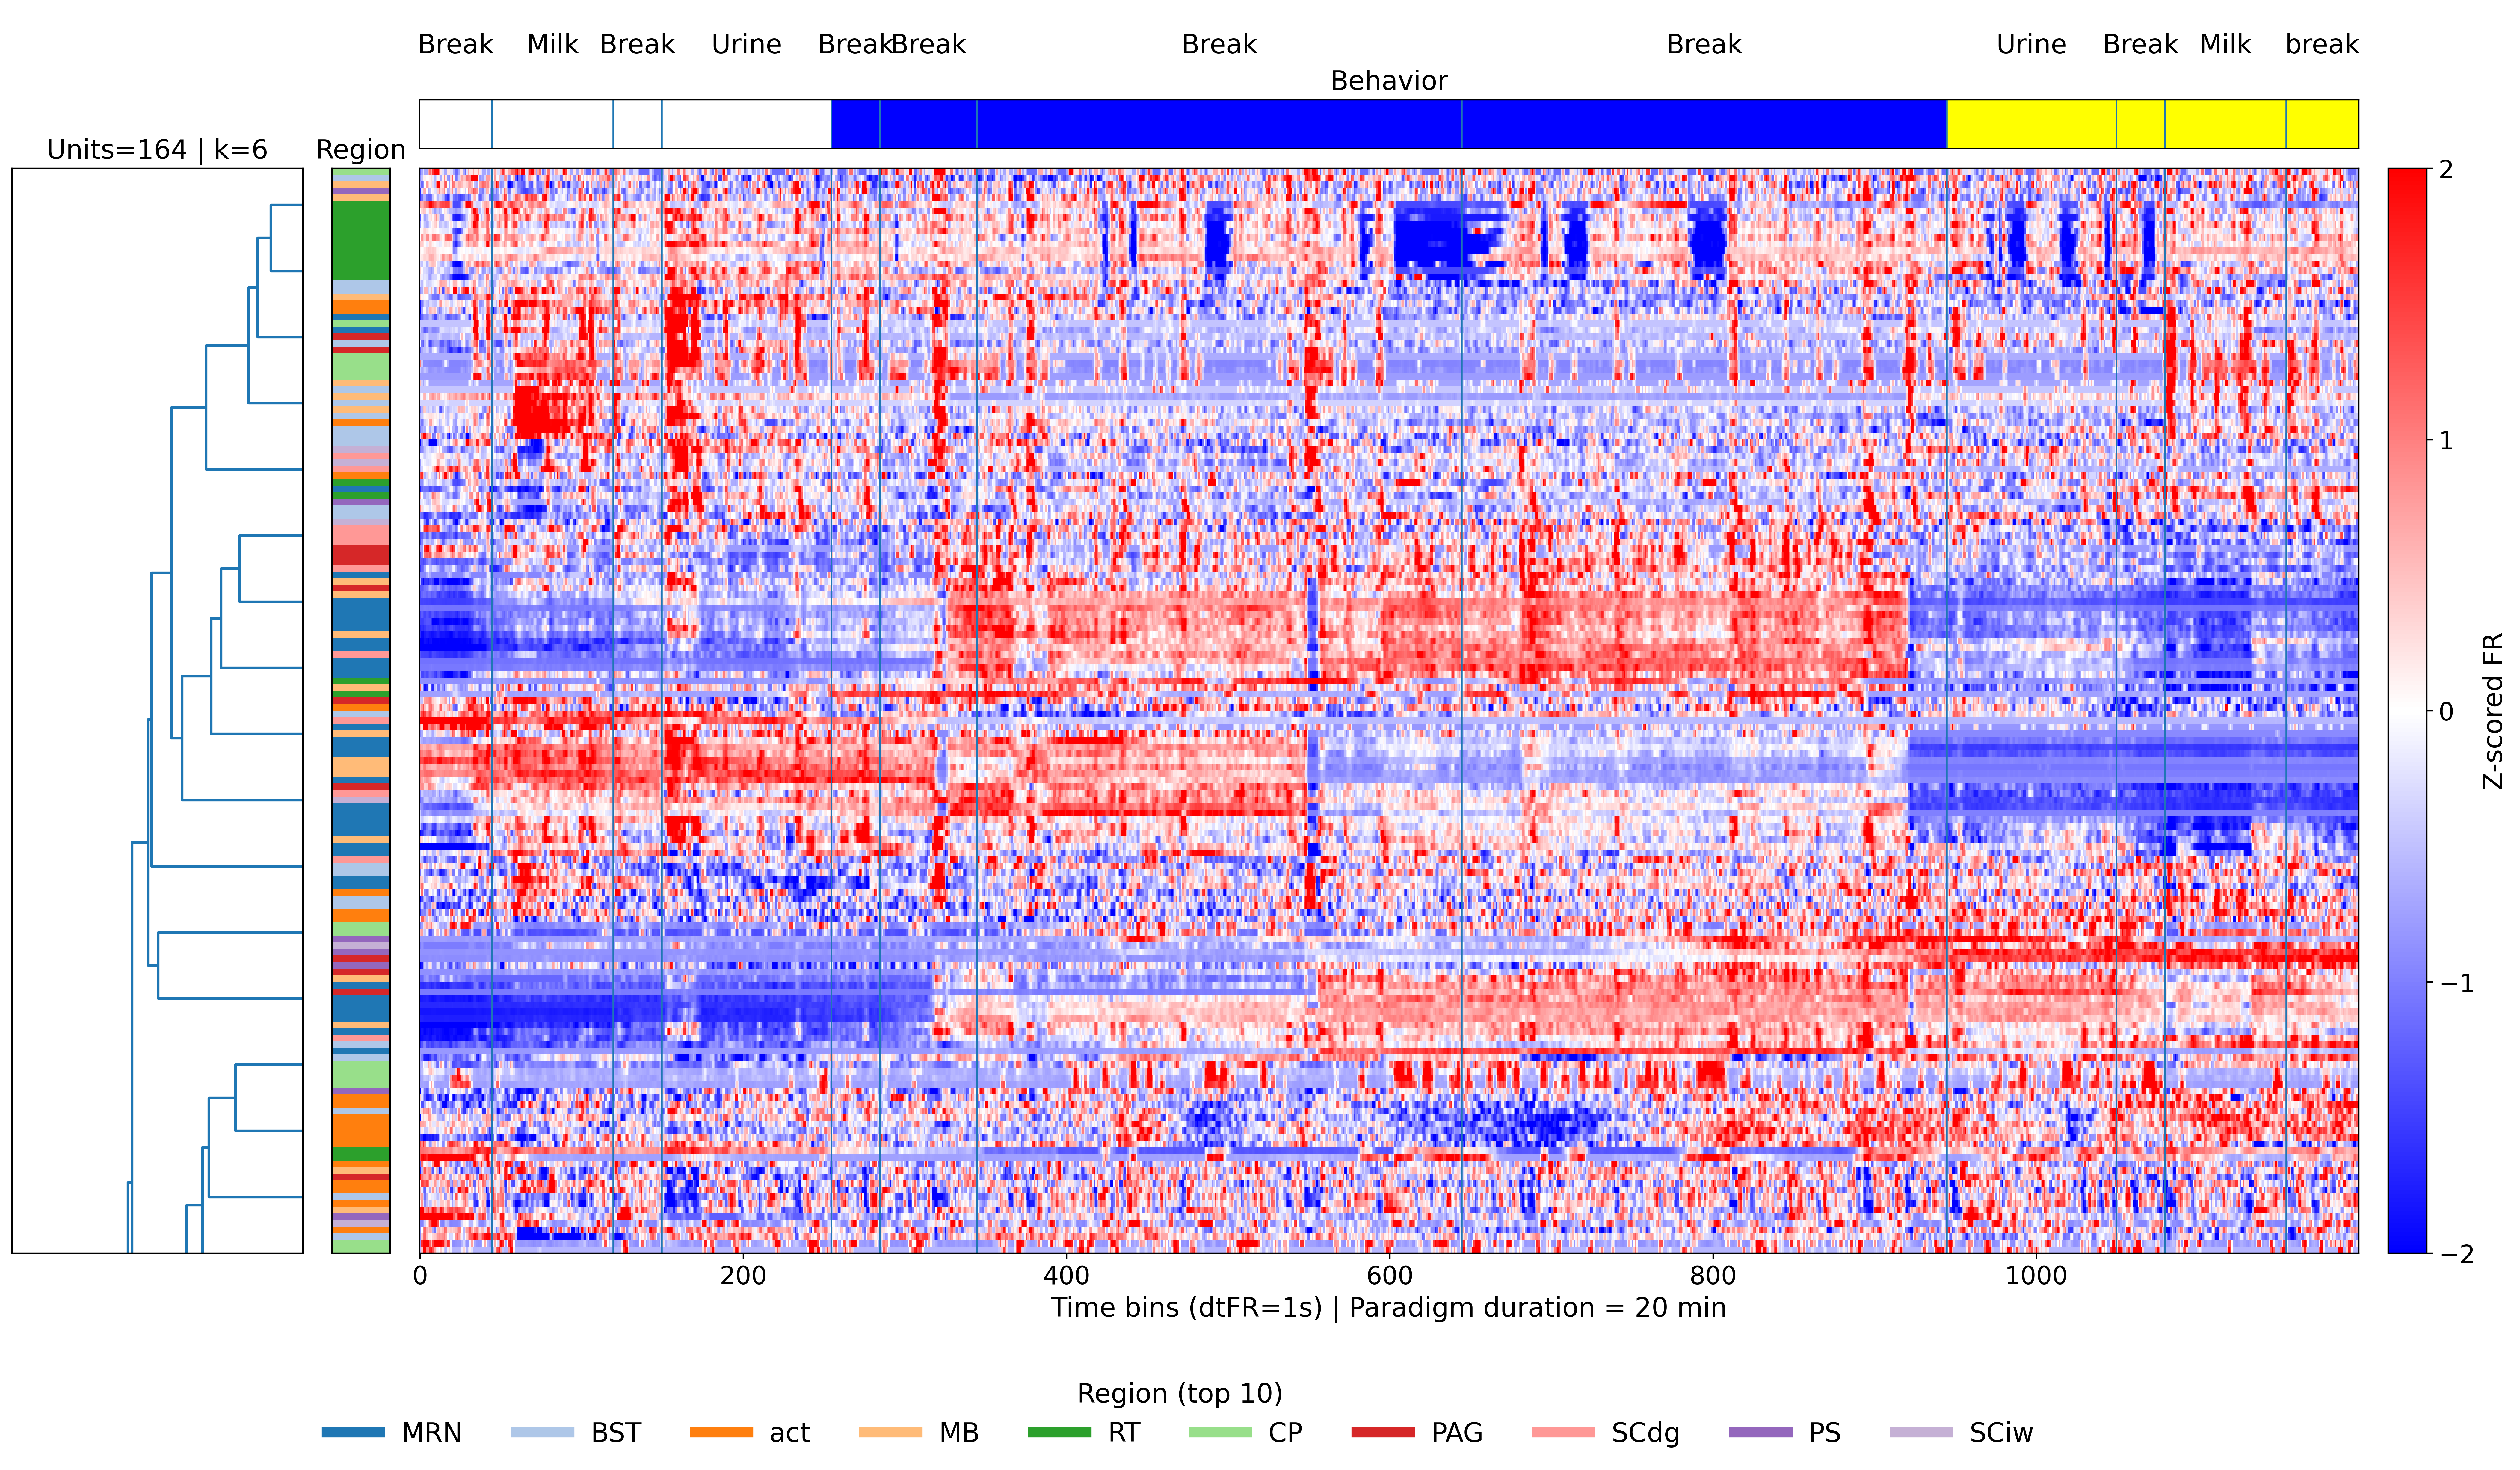

In [546]:
# =============================================================================
# ============================= PLOT GLOBAL CLUSTERGRAM =======================
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram

FONT = 16
BIN_TICK_FONTSIZE = 15  # increase heatmap x tick labels here

# --- region label helper: ONLY acronym (no id) ---
def region_label_string_no_id(rid: int) -> str:
    if "region_id_to_acr" in globals() and rid in region_id_to_acr:
        return str(region_id_to_acr[rid])
    if "region_label_string" in globals():
        s = region_label_string(rid)
        return s.split(" (id=")[0].strip()
    return str(rid)

fig = plt.figure(figsize=(26, 14), dpi=400)

# NOTE: now 4 columns (no obs strip) + 1 colorbar column
gs = fig.add_gridspec(
    nrows=3, ncols=4,
    width_ratios=[0.9, 0.18, 6.0, 0.12],  # dendro, region, heatmap, colorbar
    height_ratios=[0.25, 0.18, 4.0],
    wspace=0.05, hspace=0.05
)

# --- blank space where dendrogram "would have been" on top rows ---
ax_blank = fig.add_subplot(gs[0:2, 0])
ax_blank.axis("off")

# dendrogram ONLY in the main row
ax_den = fig.add_subplot(gs[2, 0])
dendrogram(
    Z_opt,
    orientation="left",
    ax=ax_den,
    no_labels=True,
    color_threshold=0,
    count_sort="descending",
    distance_sort="descending",
)
ax_den.set_xticks([])
ax_den.set_yticks([])
ax_den.set_title(f"Units={nUnits2} | k={k_best}", fontsize=FONT)

# tighten dendrogram x-limits
maxd = float(np.max(Z_opt[:, 2]))
ax_den.set_xlim(maxd * 1.02, 0)

# region strip
ax_rstrip = fig.add_subplot(gs[2, 1])
ax_rstrip.imshow(region_strip[:, None], aspect="auto", interpolation="nearest", cmap=region_cmap)
ax_rstrip.set_xticks([])
ax_rstrip.set_yticks([])
ax_rstrip.set_title("Region", fontsize=FONT)

# behavior bar
ax_beh = fig.add_subplot(gs[1, 2])
ax_beh.imshow(behav_codes[None, :], aspect="auto", interpolation="nearest", cmap=behav_cmap)
ax_beh.set_xticks([])
ax_beh.set_yticks([])
ax_beh.set_title("Behavior", fontsize=FONT)

# epoch labels (single line)
ax_top = fig.add_subplot(gs[0, 2])
ax_top.set_xlim(0, nBins)
ax_top.set_ylim(0, 1)
ax_top.axis("off")
start = 0
for name, dur in zip(behavSeq, epochDurSec):
    end = start + int(round(dur / dtFR))
    cx = (start + end) / 2
    ax_top.text(cx, 0.5, name, ha="center", va="center", fontsize=FONT)
    start = end

# heatmap
ax_hm = fig.add_subplot(gs[2, 2])
im = ax_hm.imshow(H, aspect="auto", interpolation="nearest", cmap=hm_cmap, vmin=-2, vmax=2)
ax_hm.set_xlabel(f"Time bins (dtFR={dtFR}s) | Paradigm duration = {int(TOTAL_SEC/60)} min", fontsize=FONT)
ax_hm.set_yticks([])
ax_hm.tick_params(axis="x", labelsize=BIN_TICK_FONTSIZE)

# --- FORCE PERFECT Y-ALIGNMENT ACROSS ALL UNIT-AXES ---
ylim = (H.shape[0] - 0.5, -0.5)
ax_hm.set_ylim(ylim)
ax_rstrip.set_ylim(ylim)
ax_den.set_ylim(ylim)

# cluster boundaries
for b in boundaries:
    y = b - 0.5
    ax_hm.axhline(y, linewidth=0, color = "black")
    ax_rstrip.axhline(y, linewidth=0, color = "black")
    ax_den.axhline(y, linewidth=0, color = "black")

# epoch separators
for xb in epoch_edges_bins:
    ax_hm.axvline(xb - 0.5, linewidth=1)
    ax_beh.axvline(xb - 0.5, linewidth=1)

# colorbar (same row/height as heatmap+strip)
ax_cb = fig.add_subplot(gs[2, 3])
cb = fig.colorbar(im, cax=ax_cb, ticks=[-2, -1, 0, 1, 2])
cb.set_label("Z-scored FR", fontsize=FONT)
cb.ax.tick_params(labelsize=BIN_TICK_FONTSIZE)

# ------------------------- ONE LEGEND ONLY: REGIONS ---------------------------
# Make it a single line across the bottom
top_regions = region_counts.head(SHOW_TOP_N_REGION_LEGEND)
handles_reg = []
labels_reg = []
for rid in top_regions.index.astype(int):
    handles_reg.append(plt.Line2D([0], [0], color=region_colors[region_to_code[rid]], lw=6))
    labels_reg.append(region_label_string_no_id(rid))

# choose ncol so it stays on ONE row (or as close as possible)
ncol_legend = max(1, len(labels_reg))

fig.legend(handles_reg, labels_reg,
           loc="lower center",
           bbox_to_anchor=(0.5, 0.01),
           ncol=ncol_legend,          # <-- forces a single line
           frameon=False,
           fontsize=FONT,
           title=f"Region (top {len(labels_reg)})",
           title_fontsize=FONT)

fig.subplots_adjust(bottom=0.14)
plt.show()



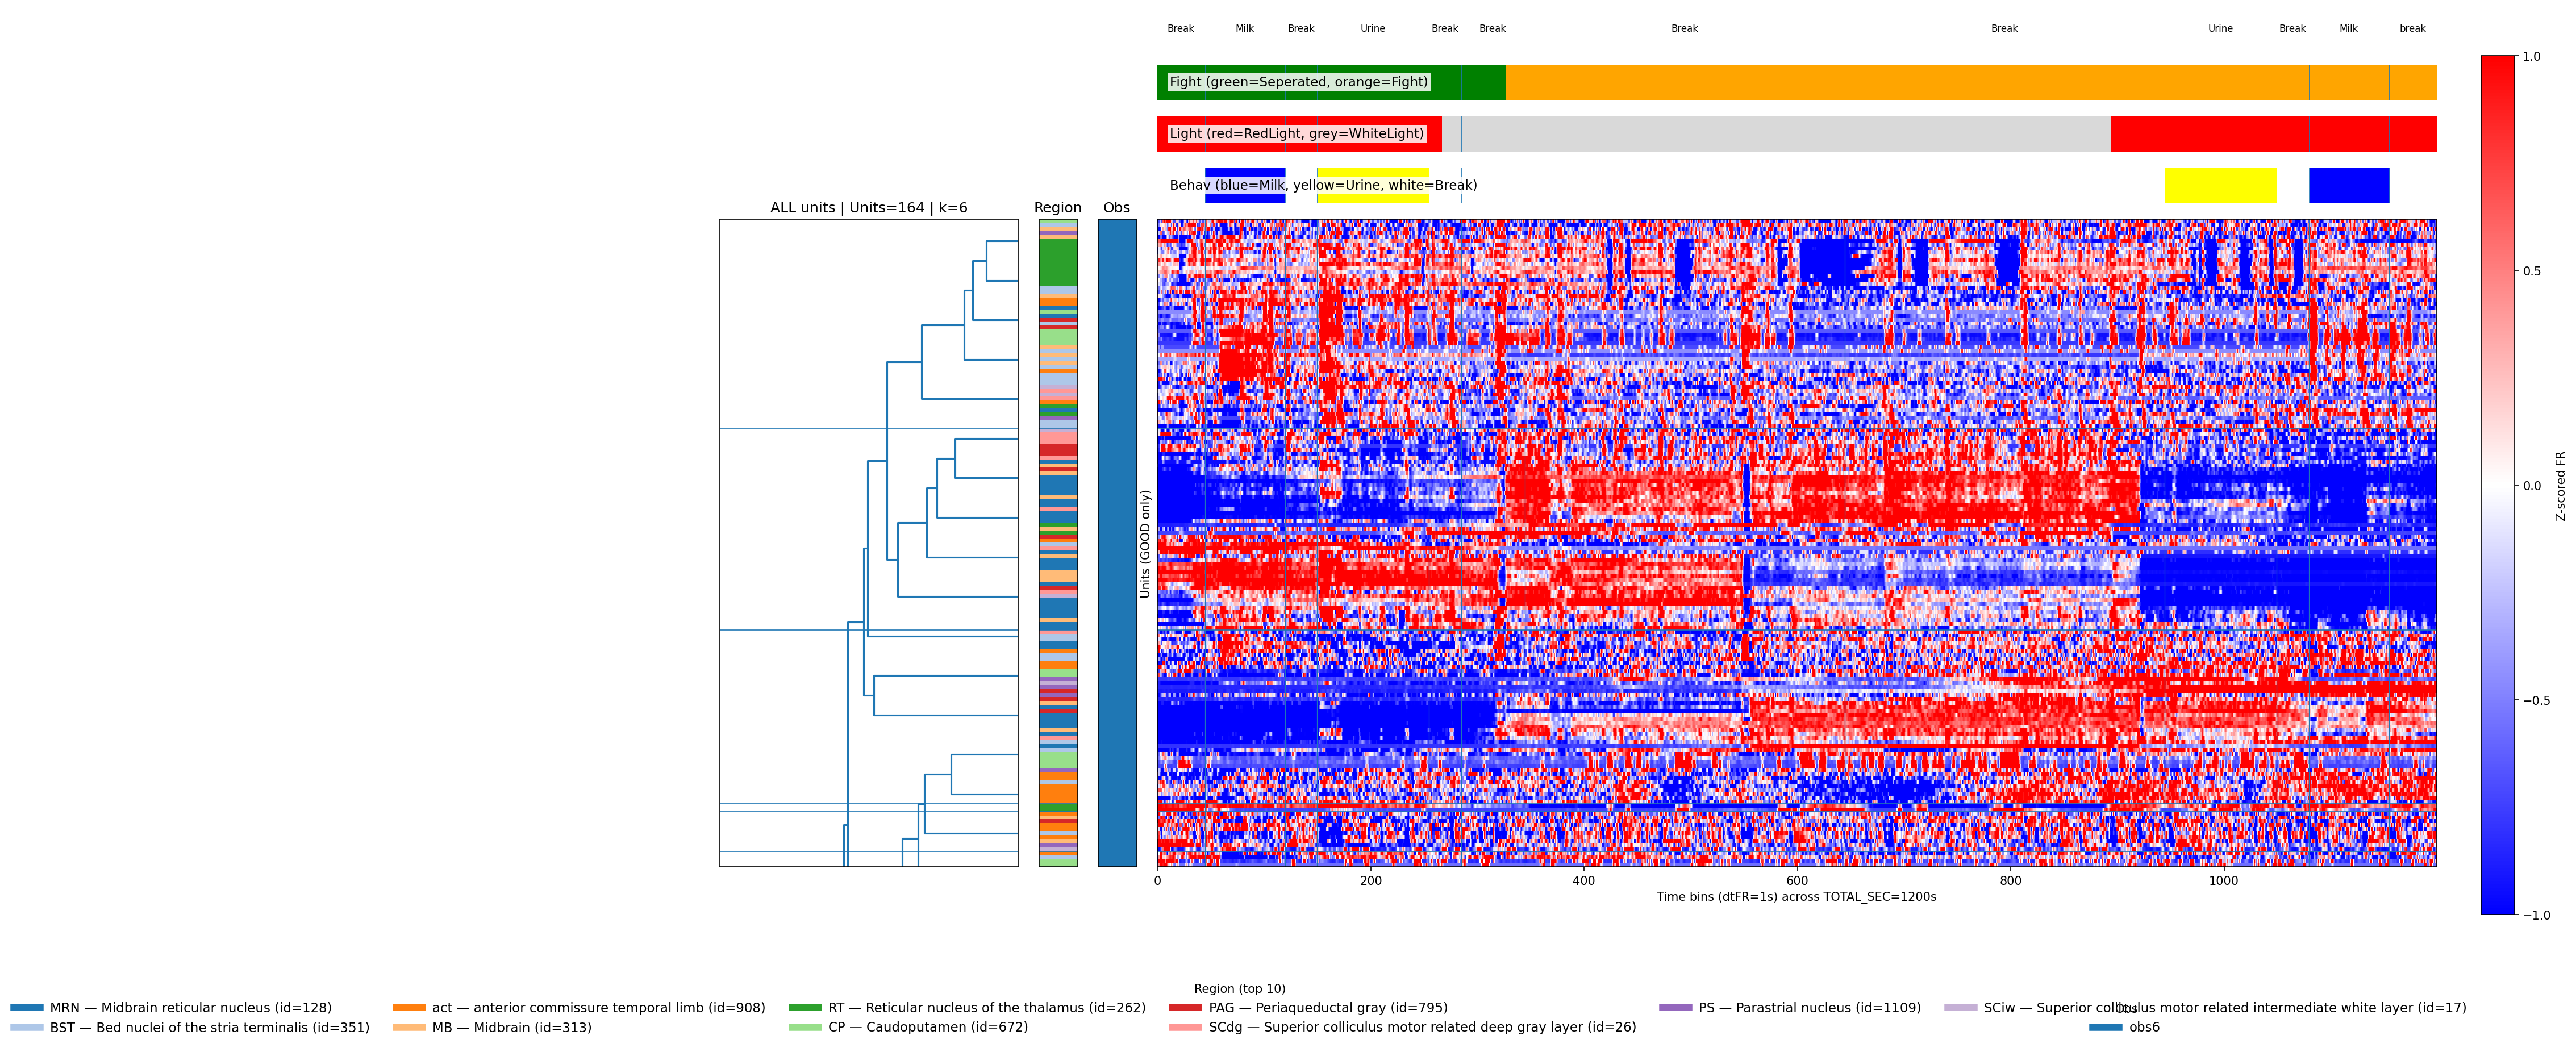

In [ ]:
# =============================================================================
# ============================= PLOT GLOBAL CLUSTERGRAM =======================
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.cluster.hierarchy import dendrogram

# ----------------------------- YOUR CONDITIONS --------------------------------
light_cond = ["RedLight", "WhiteLight", "RedLight"]
epochs_light = [4.45*60, 10.45*60, 20*60]

fight_cond = ["Seperated", "Fight"]
epochs_fight = [5.45*60, 20*60]

behavSeq = [
    "Break", "Milk", "Break", "Urine", "Break",
    "Break", "Break", "Break", "Urine", "Break",
    "Milk", "break"
]
epochDurSec = [45, 75, 30, 105, 30, 60, 60 * 5, 60 * 5, 105, 30, 75, 45]

# ------------------------- helpers (bins & colored bars) ----------------------
def _durations_to_bins(durs_sec, dt):
    return [int(round(float(d) / float(dt))) for d in durs_sec]

def _pad_bins_to_nBins(bins_list, nBins):
    total = int(np.sum(bins_list))
    if total < nBins:
        bins_list = list(bins_list)
        bins_list[-1] += (nBins - total)
    return bins_list

def _codes_from_epochs(names, bins_list, name_to_code, nBins):
    """Return int codes length nBins based on epoch names + bin durations."""
    codes = np.zeros(nBins, dtype=np.int16)
    cursor = 0
    for nm, nb in zip(names, bins_list):
        nb = int(nb)
        code = name_to_code.get(str(nm).strip().lower(), 0)
        if cursor < nBins:
            codes[cursor:min(cursor+nb, nBins)] = code
        cursor += nb
        if cursor >= nBins:
            break
    return codes

def _edges_from_bins(bins_list, nBins):
    """Edges (in bins) where epoch changes, excluding 0 and nBins."""
    edges = []
    c = 0
    for nb in bins_list[:-1]:
        c += int(nb)
        if 0 < c < nBins:
            edges.append(c)
    return edges

# Convert durations to bins and pad to nBins (so bars cover exact heatmap width)
light_bins = _pad_bins_to_nBins(_durations_to_bins(epochs_light, dtFR), nBins)
fight_bins = _pad_bins_to_nBins(_durations_to_bins(epochs_fight, dtFR), nBins)
behav_bins = _pad_bins_to_nBins(_durations_to_bins(epochDurSec, dtFR), nBins)

# Build code vectors
light_name_to_code = {"redlight": 0, "whitelight": 1}
fight_name_to_code = {"seperated": 0, "separated": 0, "fight": 1}  # accept spelling variants
behav_name_to_code = {"break": 0, "milk": 1, "urine": 2}

light_codes = _codes_from_epochs(light_cond, light_bins, light_name_to_code, nBins)
fight_codes = _codes_from_epochs(fight_cond, fight_bins, fight_name_to_code, nBins)
behav_codes = _codes_from_epochs(behavSeq, behav_bins, behav_name_to_code, nBins)

# Edges for separators (optional)
light_edges = _edges_from_bins(light_bins, nBins)
fight_edges = _edges_from_bins(fight_bins, nBins)
behav_edges = _edges_from_bins(behav_bins, nBins)

# Colormaps (exact colors requested)
# Light: RedLight=red, WhiteLight=light grey
light_cmap = mpl.colors.ListedColormap(["red", "#d9d9d9"])

# Fight: Seperated=green, Fight=orange
fight_cmap = mpl.colors.ListedColormap(["green", "orange"])

# Behav: Break=white, Milk=blue, Urine=yellow
behav_cmap = mpl.colors.ListedColormap(["white", "blue", "yellow"])

# Shared x geometry for PERFECT alignment
x0, x1 = -0.5, nBins - 0.5
extent_1row = [x0, x1, 0, 1]   # 1-row bars
extent_hm = [x0, x1, H.shape[0] - 0.5, -0.5]  # keep your "unit 0 at top" convention

# ----------------------------- figure layout ----------------------------------
fig = plt.figure(figsize=(26, 14), dpi=150)
gs = fig.add_gridspec(
    nrows=5, ncols=4,
    width_ratios=[1.4, 0.18, 0.18, 6.0],          # dendro, region strip, obs strip, heatmap
    height_ratios=[0.25, 0.22, 0.22, 0.22, 4.0],  # epoch labels, fight, light, behav, main
    wspace=0.05, hspace=0.10                      # more vertical space (but titles are inside bars now)
)

# --- blank where dendrogram would have been on top rows ---
ax_blank = fig.add_subplot(gs[0:4, 0])
ax_blank.axis("off")

# ----------------------------- dendrogram -------------------------------------
ax_den = fig.add_subplot(gs[4, 0])
dendrogram(
    Z_opt,
    orientation="left",
    ax=ax_den,
    no_labels=True,
    color_threshold=0,
    count_sort="descending",
    distance_sort="descending",
)
ax_den.set_xticks([])
ax_den.set_yticks([])
ax_den.set_title(f"ALL units | Units={nUnits2} | k={k_best}", fontsize=12)

# ----------------------------- strips -----------------------------------------
ax_rstrip = fig.add_subplot(gs[4, 1])
ax_rstrip.imshow(region_strip[:, None], aspect="auto", interpolation="nearest", cmap=region_cmap,
                 extent=[0, 1, H.shape[0] - 0.5, -0.5])
ax_rstrip.set_xticks([])
ax_rstrip.set_yticks([])
ax_rstrip.set_title("Region", fontsize=12)

ax_ostrip = fig.add_subplot(gs[4, 2])
ax_ostrip.imshow(obs_strip[:, None], aspect="auto", interpolation="nearest", cmap=obs_cmap,
                 extent=[0, 1, H.shape[0] - 0.5, -0.5])
ax_ostrip.set_xticks([])
ax_ostrip.set_yticks([])
ax_ostrip.set_title("Obs", fontsize=12)

# ----------------------------- epoch labels -----------------------------------
ax_top = fig.add_subplot(gs[0, 3])
ax_top.set_xlim(x0, x1)
ax_top.set_ylim(0, 1)
ax_top.axis("off")

cursor = 0
for name, nb in zip(behavSeq, behav_bins):
    nb = int(nb)
    start = cursor
    end = min(cursor + nb, nBins)
    cx = (start + end - 1) / 2  # center in bin coordinates
    ax_top.text(cx, 0.5, str(name), ha="center", va="center", fontsize=8)
    cursor += nb
    if cursor >= nBins:
        break

# ----------------------------- colored condition bars -------------------------
def _format_bar_axis(ax, label_text):
    ax.set_xlim(x0, x1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)
    # title INSIDE bar (left), with a white textbox so it stays readable on colors
    ax.text(
        0.01, 0.5, label_text,
        transform=ax.transAxes,
        ha="left", va="center",
        fontsize=11,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=2.0)
    )

ax_fight = fig.add_subplot(gs[1, 3])
ax_fight.imshow(fight_codes[None, :], aspect="auto", interpolation="nearest",
                cmap=fight_cmap, vmin=0, vmax=1, extent=extent_1row)
_format_bar_axis(ax_fight, "Fight (green=Seperated, orange=Fight)")

ax_light = fig.add_subplot(gs[2, 3])
ax_light.imshow(light_codes[None, :], aspect="auto", interpolation="nearest",
                cmap=light_cmap, vmin=0, vmax=1, extent=extent_1row)
_format_bar_axis(ax_light, "Light (red=RedLight, grey=WhiteLight)")

ax_beh = fig.add_subplot(gs[3, 3])
ax_beh.imshow(behav_codes[None, :], aspect="auto", interpolation="nearest",
              cmap=behav_cmap, vmin=0, vmax=2, extent=extent_1row)
_format_bar_axis(ax_beh, "Behav (blue=Milk, yellow=Urine, white=Break)")

# ----------------------------- heatmap ----------------------------------------
ax_hm = fig.add_subplot(gs[4, 3])
im = ax_hm.imshow(H, aspect="auto", interpolation="nearest", cmap=hm_cmap,
                  vmin=-1, vmax=1, extent=extent_hm)
ax_hm.set_xlim(x0, x1)
ax_hm.set_xlabel(f"Time bins (dtFR={dtFR}s) across TOTAL_SEC={TOTAL_SEC}s")
ax_hm.set_ylabel("Units (GOOD only)")
ax_hm.set_yticks([])

# --- FORCE PERFECT Y-ALIGNMENT ACROSS ALL UNIT-AXES ---
ylim = (H.shape[0] - 0.5, -0.5)
ax_hm.set_ylim(ylim)
ax_rstrip.set_ylim(ylim)
ax_ostrip.set_ylim(ylim)
ax_den.set_ylim(ylim)

# ----------------------------- separators -------------------------------------
# Use behav epoch edges as your main separators (and also draw on the bars)
for xb in behav_edges:
    x = xb - 0.5
    ax_hm.axvline(x, linewidth=0.6)
    ax_fight.axvline(x, linewidth=0.4)
    ax_light.axvline(x, linewidth=0.4)
    ax_beh.axvline(x, linewidth=0.4)

# If you also want separators for fight/light boundaries (optional), uncomment:
# for xb in fight_edges:
#     x = xb - 0.5
#     ax_fight.axvline(x, linewidth=0.8)
# for xb in light_edges:
#     x = xb - 0.5
#     ax_light.axvline(x, linewidth=0.8)

# cluster boundaries
for b in boundaries:
    y = b - 0.5
    ax_hm.axhline(y, linewidth=0.8)
    ax_rstrip.axhline(y, linewidth=0.8)
    ax_ostrip.axhline(y, linewidth=0.8)
    ax_den.axhline(y, linewidth=0.8)

# ----------------------------- colorbar ---------------------------------------
cax = fig.add_axes([0.92, 0.12, 0.015, 0.72])
cb = fig.colorbar(im, cax=cax, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Z-scored FR")

# ----------------------------- legends ----------------------------------------
# region legend (top N only)
top_regions = region_counts.head(SHOW_TOP_N_REGION_LEGEND)
handles_reg = []
labels_reg = []
for rid in top_regions.index.astype(int):
    handles_reg.append(plt.Line2D([0], [0], color=region_colors[region_to_code[rid]], lw=6))
    labels_reg.append(region_label_string(rid))

fig.legend(handles_reg, labels_reg,
           loc="lower center",
           bbox_to_anchor=(0.36, 0.01),
           ncol=min(6, len(labels_reg)),
           frameon=False,
           fontsize=11,
           title=f"Region (top {len(labels_reg)})")

# obs legend
handles_obs = [plt.Line2D([0], [0], color=obs_colors[i], lw=6) for i in range(len(obs_names))]
fig.legend(handles_obs, obs_names,
           loc="lower center",
           bbox_to_anchor=(0.76, 0.01),
           ncol=min(6, len(obs_names)),
           frameon=False,
           fontsize=11,
           title="Obs")

fig.subplots_adjust(bottom=0.16)
plt.show()

